In [1]:
#@title Importamos las librerías necesarias.
# Import the necessary libraries.
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
import cv2
import random
import os
import math
import statistics
import pandas as pd
from PIL import Image
from collections import defaultdict
from google.colab import drive
from google.colab.patches import cv2_imshow

In [2]:
#@title Configurando el Drive.
# Setting up Drive.
drive.mount('/content/drive')
os.chdir('/content/drive/MyDrive/Trabajo de Grado')
print(os.getcwd())

Mounted at /content/drive
/content/drive/MyDrive/Trabajo de Grado


In [3]:
#@title Descargamos los paquetes necesarios.
# Download the necessary packages.
!pip install ultralytics
!pip install torch torchaudio torchvision
!pip install torchmetrics
!pip install pycocotools
!pip install gTTS


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.7/46.7 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 26.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.1/58.1 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.0/91.0 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 11.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.2/98.2 kB 4.7 MB/s eta 0:00:00
  Attempting uninstall: click
    Found existing installation: click 8.5.0
    Uninstalling click-8.5.0:
      Successfully uninstalled click-8.5.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
wandb 0.28.1 requires click>=8.2.0, but you have click 8.1.8 which is incompatible.
huggingface-hub 1.31.0 requires click<9.0.0,>=8.4.2, but you have click 8.1.8 which is incompatible.
spacy 3.8.16 require

In [4]:
#@title Descargamos algunas funciones del repositorio de Pytorch para facilitar el entrenamiento y evaluación de los modelos.
# Download some functions from Pytorch's Github Repository to ease the model's training and evaluation.
!wget https://raw.githubusercontent.com/pytorch/vision/main/references/detection/engine.py
!wget https://raw.githubusercontent.com/pytorch/vision/main/references/detection/utils.py
!wget https://raw.githubusercontent.com/pytorch/vision/main/references/detection/coco_utils.py
!wget https://raw.githubusercontent.com/pytorch/vision/main/references/detection/coco_eval.py
!wget https://raw.githubusercontent.com/pytorch/vision/main/references/detection/transforms.py

--2026-09-28 20:00:41--  https://raw.githubusercontent.com/pytorch/vision/main/references/detection/engine.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.109.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 4063 (4.0K) [text/plain]
Saving to: ‘engine.py.3’

engine.py.3         100%[===================>]   3.97K  --.-KB/s    in 0.001s  

2026-09-28 20:00:41 (2.85 MB/s) - ‘engine.py.3’ saved [4063/4063]

--2026-09-28 20:00:41--  https://raw.githubusercontent.com/pytorch/vision/main/references/detection/utils.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 8388 (8.2K) [text/plai

In [5]:
#@title Metodos usados para el preprocesamiento y visualización de las imagenes.
# Methods used for preprocessing and visualizing the images.

#Metodo para obtener las annotaciones en un mismo formato.
#Method to obtain all annotations in the same format.
def parse_annotation(annotation_text):
    labels = []

    for line in annotation_text.strip().split("\n"):
          polygon = []
          values = line.split()

          for n in values:
            polygon.append(float(n))
          labels.append(polygon)

    return labels

#Metodo para dibujar poligonos/bounding boxes en la imagen.
#Method to draw the polygons/bounding boxes in the image.
def draw_polygons(image, labels, color=(86,5,145)):
    img = image.copy()

    h, w = img.shape[:2]
    for n in labels:
      if len(n) == 5:
        id_class = int(n[0])
        x1 = int((n[1] - n[3]/2) * w)
        y1 = int((n[2] - n[4]/2) * h)

        x2 = int((n[1] + n[3]/2) * w)
        y2 = int((n[2] + n[4]/2) * h)

        cv2.rectangle(img,(x1, y1),(x2, y2),color,2)

        cv2.putText(img, str(id_class), (x1, y1 - 5), cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 1)

      else:
        id_class = int(n[0])
        coords = np.array(n[1:], dtype=np.float32)

        coords[0::2] *= w  # x
        coords[1::2] *= h  # y

        pts = coords.reshape(-1, 2).astype(np.int32)

        cv2.polylines(img, [pts], isClosed=True, color=color, thickness=2)
        cv2.putText(img, str(id_class), (pts[0,0], pts[0,1]-5), cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 1)

    return img

#Metodo para rotar las bounding boxes.
#Method to rotate the bunding boxes.
def rotate_label(label, M, w, h):
  if len(label) == 5:
    id_class, xc, yc, bw, bh = label

    x1 = (xc - bw / 2) * w
    y1 = (yc - bh / 2) * h

    x2 = (xc + bw / 2) * w
    y2 = (yc + bh / 2) * h

    corners = np.array([
        [x1, y1],
        [x2, y1],
        [x2, y2],
        [x1, y2]
    ])

    ones = np.ones((4, 1))
    corners_h = np.hstack([corners, ones])

    rotated = corners_h @ M.T
    xmin = rotated[:,0].min()
    xmax = rotated[:,0].max()

    ymin = rotated[:,1].min()
    ymax = rotated[:,1].max()

    #Normalizar
    xc = (xmin + xmax) / 2 / w
    yc = (ymin + ymax) / 2 / h

    bw = (xmax - xmin) / w
    bh = (ymax - ymin) / h

    return [int(id_class), xc, yc, bw, bh]

  else:
    id_class = int(label[0])

    pts = np.array(label[1:]).reshape(-1, 2)
    pts[:, 0] *= w
    pts[:, 1] *= h

    ones = np.ones((pts.shape[0], 1))
    pts_h = np.hstack([pts, ones])

    rotated_pts = pts_h @ M.T
    rotated_pts[:, 0] /= w
    rotated_pts[:, 1] /= h

    new_label = [id_class]
    new_label.extend(rotated_pts.flatten().tolist())

    return new_label


#Metodos que manejan la logica de las transformaciones de Rotate y Resize en una imagen (Y su respectiva transformación a las bounding boxes)
#Method that manage the logic of the Rotation and Resizing of an Image (And their respective bounding box transforms)
def resize_rotate_yolo(image, label):

  scale = 1.0
  h, w = image.shape[:2]

  image_copy = image.copy()
  image_copy = cv2.cvtColor(image_copy, cv2.COLOR_GRAY2BGR)
  image_copy = cv2.resize(image_copy, (512, 512))

  w,h = image_copy.shape[:2]
  center = (w / 2, h / 2)

  # Perform the rotation
  M = cv2.getRotationMatrix2D(center, 5, scale)
  image_copy = cv2.warpAffine(image_copy, M, (w, h))

  new_label = []
  for label in label:
      new_label.append(rotate_label(label, M, w, h))

  return image_copy, new_label


def resize_yolo(image):

  scale = 1.0
  h, w = image.shape[:2]

  image_copy = image.copy()
  image_copy = cv2.cvtColor(image_copy, cv2.COLOR_GRAY2BGR)
  image_copy = cv2.resize(image_copy, (640, 640))

  return image_copy


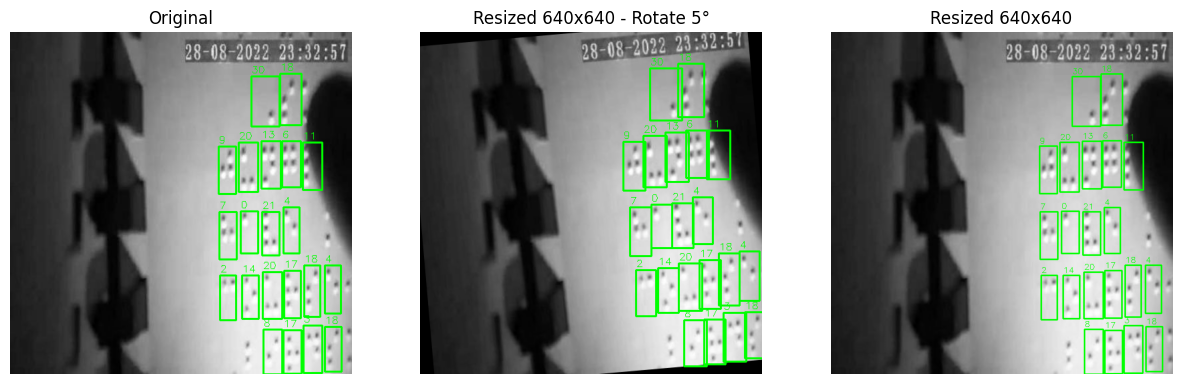

In [ ]:
#@title Miremos una muestra y sus respectivas transformaciones.
# Lets check a sample and its transforms.
train_path = "Dataset - Yolo/train/"
test_path = "Dataset - Yolo/test/"
val_path = "Dataset - Yolo/val/"

images_jpg = sorted(os.listdir(f'{train_path}/images'))
labels_txt = sorted(os.listdir(f'{train_path}/labels'))

indx = random.choice(range(len(images_jpg)))

image_sample = cv2.imread(os.path.join(train_path, "images", images_jpg[indx]), cv2.IMREAD_GRAYSCALE)
label_sample = open(os.path.join(train_path, "labels", labels_txt[indx]), "r").read()
label_sample = parse_annotation(label_sample)

img_color, label = resize_rotate_yolo(image_sample, label_sample)
img_resized = resize_yolo(image_sample)

image_sample = cv2.cvtColor(image_sample, cv2.COLOR_GRAY2BGR)

og_boxes = draw_polygons(image_sample, label_sample)
img_boxes = draw_polygons(img_color, label)
img_resized_boxes = draw_polygons(img_resized, label_sample)

plt.figure(figsize=(15,15))
plt.subplot(1,3,1)
plt.title("Original")
plt.imshow(cv2.cvtColor(og_boxes, cv2.COLOR_BGR2RGB))
plt.axis("off")

plt.subplot(1,3,2)
plt.title("Resized 640x640 - Rotate 5°")
plt.imshow(cv2.cvtColor(img_boxes, cv2.COLOR_BGR2RGB))
plt.axis("off")

plt.subplot(1,3,3)
plt.title("Resized 640x640")
plt.imshow(cv2.cvtColor(img_resized_boxes, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

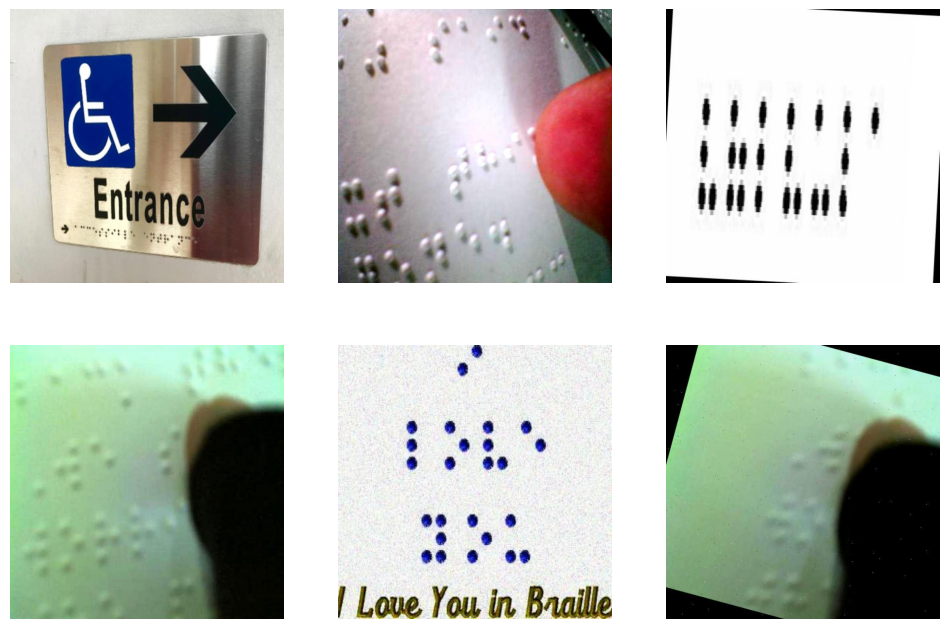

In [ ]:
#@title Collage de 6 muestras
train_path = "Dataset - Yolo/train/"
images_jpg = sorted(os.listdir(f'{train_path}/images'))
indxs = random.choices(images_jpg,k=6)

image_sample = []

for indx in indxs:
  image_sample.append(cv2.imread(os.path.join(train_path, "images", indx), cv2.IMREAD_COLOR))

plt.figure(figsize=(12,8))
plt.subplot(2,3,1)
plt.imshow(cv2.cvtColor(image_sample[0], cv2.COLOR_BGR2RGB))
plt.axis("off")

plt.subplot(2,3,2)
plt.imshow(cv2.cvtColor(image_sample[1], cv2.COLOR_BGR2RGB))
plt.axis("off")

plt.subplot(2,3,3)
plt.imshow(cv2.cvtColor(image_sample[2], cv2.COLOR_BGR2RGB))
plt.axis("off")

plt.subplot(2,3,4)
plt.imshow(cv2.cvtColor(image_sample[3], cv2.COLOR_BGR2RGB))
plt.axis("off")

plt.subplot(2,3,5)
plt.imshow(cv2.cvtColor(image_sample[4], cv2.COLOR_BGR2RGB))
plt.axis("off")

plt.subplot(2,3,6)
plt.imshow(cv2.cvtColor(image_sample[5], cv2.COLOR_BGR2RGB))
plt.axis("off")

plt.show()

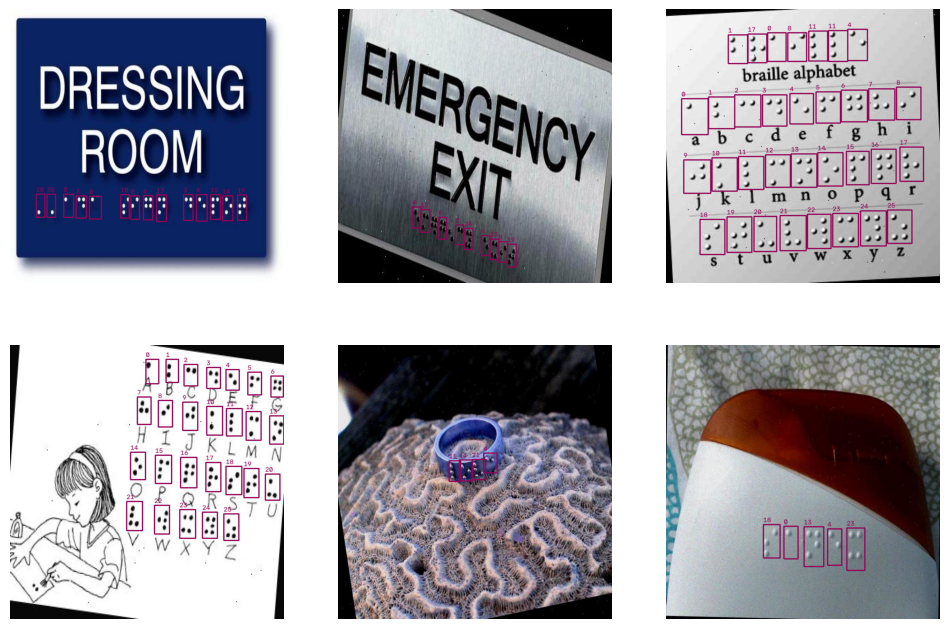

In [ ]:
#@title Collage de 6 muestras etiquetadas
train_path = "Dataset - Yolo/train/"
images_jpg = sorted(os.listdir(f'{train_path}/images'))
labels_txt = sorted(os.listdir(f'{train_path}/labels'))
indxs = random.choices(range(len(images_jpg)),k=6)

image_sample = []
label_sample = []

for indx in indxs:
  image_sample.append(cv2.imread(os.path.join(train_path, "images", images_jpg[indx]), cv2.IMREAD_COLOR))
  label = open(os.path.join(train_path, "labels", labels_txt[indx]), "r").read()
  label = parse_annotation(label)
  label_sample.append(label)

plt.figure(figsize=(12,8))
plt.subplot(2,3,1)
img_boxes = draw_polygons(image_sample[0], label_sample[0])
plt.imshow(cv2.cvtColor(img_boxes, cv2.COLOR_BGR2RGB))
plt.axis("off")

plt.subplot(2,3,2)
img_boxes = draw_polygons(image_sample[1], label_sample[1])
plt.imshow(cv2.cvtColor(img_boxes, cv2.COLOR_BGR2RGB))
plt.axis("off")

plt.subplot(2,3,3)
img_boxes = draw_polygons(image_sample[2], label_sample[2])
plt.imshow(cv2.cvtColor(img_boxes, cv2.COLOR_BGR2RGB))
plt.axis("off")

plt.subplot(2,3,4)
img_boxes = draw_polygons(image_sample[3], label_sample[3])
plt.imshow(cv2.cvtColor(img_boxes, cv2.COLOR_BGR2RGB))
plt.axis("off")

plt.subplot(2,3,5)
img_boxes = draw_polygons(image_sample[4], label_sample[4])
plt.imshow(cv2.cvtColor(img_boxes, cv2.COLOR_BGR2RGB))
plt.axis("off")

plt.subplot(2,3,6)
img_boxes = draw_polygons(image_sample[5], label_sample[5])
plt.imshow(cv2.cvtColor(img_boxes, cv2.COLOR_BGR2RGB))
plt.axis("off")

plt.show()

In [ ]:
from gtts import gTTS
from IPython.display import Audio

#@title Definimos el modulo de Text-to-Speech
def play_text(input_text, lan="en"):
    file_name = "gtts_output.wav"
    tts = gTTS(input_text, lang=lan)
    tts.save(file_name)
    sound_file = file_name
    return Audio(sound_file, autoplay=True)

# Entrenando modelos en el framework Ultralytics

## Entrenamos una YOLO (You Only Look Once)

In [6]:
#@title Librerías necesarias.
# Necessary Libraries.
import torch
import ultralytics
from ultralytics import YOLO
from ultralytics import RTDETR

import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from torchvision.ops import nms

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.


In [7]:
#@title Metodos de postprocesamiento

def nms_Yolo(results, image, iou=0.3):
    # Obtenemos las cajas, los puntajes y las clases.
    # Get the boxes, scores and classes.
    boxes = results[0].boxes.xyxy
    scores = results[0].boxes.conf
    classes = results[0].boxes.cls

    # Aplicar NMS manualmente con IoU
    # Apply NMS manually with IoU
    keep = nms(boxes, scores, iou_threshold=iou)

    # Filtrar resultados
    # Filter the results
    filtered_boxes = boxes[keep]
    filtered_scores = scores[keep]
    filtered_classes = classes[keep]

    image = results[0].orig_img.copy()

    # Usa las predicciones filtradas con NMS
    # Use filtered predictions with NMS
    for i in range(len(keep)):
        cls = int(filtered_classes[i])
        conf = float(filtered_scores[i])
        x1, y1, x2, y2 = map(int, filtered_boxes[i])
        label = f"{results[0].names[cls]}"

        # Dibujar rectángulo
        # Draw the rectangle
        cv2.rectangle(image, (x1, y1), (x2, y2), (0, 255, 255), 2)

        # Etiqueta con fondo
        # Label with background
        (tw, th), _ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.6, 1)
        cv2.rectangle(image, (x1, y1 - th - 4), (x1 + tw, y1), (0, 255, 255), -1)
        cv2.putText(image, label, (x1, y1 - 4), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 0, 0), 1)


    text = spatial_organization(results, keep, filtered_boxes, filtered_classes)

    return image, text

def spatial_organization(results, keep, filtered_boxes, filtered_classes):
    # Declaramos un diccionario para caracteres especiales
    special_characters = {
        'a_tilde': 'á', 'ampersand': '&', 'apostrophe': "'", 'asterisk': '*', 'close_parenthesis': ')', 'closequotation': '"', 'colon': ':', 'comma': ',', 'e_tilde': 'é', 'exclamation_mark': '!', 'greaterthan': '>', 'hyphen': '-', 'i_tilde': 'í', 'lessthan': '<', 'minus': '-', 'n_tilde': 'ñ', 'o_tilde': 'ó', 'open_parenthesis': '(', 'parentheses': '()', 'period': '.', 'question_mark': '?', 'semicolon': ';', 'slash': '/', 'u_dieresis': 'ü', 'u_tilde': 'ú'
    }
    numbers = {
        'j': '0', 'a': '1', 'b': '2', 'c': '3', 'd': '4', 'e': '5', 'f': '6', 'g': '7', 'h': '8', 'i': '9'
    }
    #Instanciamos una lista para guardar la altura de las bounding boxes
    y_difference = []
    # Agrupar por líneas (por y1)
    line_groups = defaultdict(list)
    #Revisamos que hayan bounding boxes que organizar
    lenght = len(filtered_boxes)
    if lenght == 0:
      return []
    else:
      for n in range(len(keep)):
        y_difference.append(np.abs(filtered_boxes[n][1].item()-filtered_boxes[n][3].item()))

    #Sacamos un promedio de las alturas de todas las letras
    y_threshold = statistics.mean(y_difference)
    y_threshold = y_threshold * 0.9 # tolerancia vertical en píxeles

    #Ordenamos las cajas respecto a sus posiciones en X (De izquierda a derecha)
    ordered_boxes = sorted(zip(filtered_boxes,filtered_classes), key= lambda x: x[0][0])
    filtered_boxes = [x for x,y in ordered_boxes]
    filtered_classes = [y for x,y in ordered_boxes]

    # Agrupar letras por líneas
    for i in range(len(keep)):
        #Extraer los datos de todas las detecciones, clase como string, bounding box y la posición en Y centrada
        cls = int(filtered_classes[i])
        letra = results[0].names[cls].lower()
        x1, y1, x2, y2 = filtered_boxes[i].tolist()
        y_center = (y1 + y2) / 2

        # Asignar a una línea existente o crear una nueva
        added = False

        #Iteramos por todas las bounding boxes mirando cuales están dentro de la tolerancia vertical de la primera, así separaos las lineas
        for key in line_groups:
            if abs(key - y_center) < y_threshold:
                line_groups[key].append((x1, letra))
                added = True
                break
        if not added:
            line_groups[y_center].append((x1, letra))

    # Ordenamos las líneas verticalmente (de arriba hacia abajo)
    sorted_lines = sorted(line_groups.items(), key=lambda x: x[0])

    # Instanciamos lista para el texto final
    texto_final = []
    for _, letras in sorted_lines:
        #letras.sort(key=lambda x: x[0])  # ordenar letras por x

        #Aplicar transforamciones a caracteres especiales
        for n in range(len(letras)):
            if letras[n][1] in special_characters:
                letras[n] = (letras[n][0], special_characters[letras[n][1]])
            if letras[n][1] == 'capital':
                letras[n] = (letras[n][0], '')
                if n+1 < len(letras):
                  letras[n+1] = (letras[n+1][0], letras[n+1][1].upper())
            if letras[n][1] == 'number_sign':
                letras[n] = (letras[n][0], '')
                if n+1 < len(letras):
                  if letras[n+1][1] in numbers:
                    letras[n+1] = (letras[n+1][0], numbers[letras[n+1][1]])
            if letras[n][1] == 'letter_sign':
                letras[n] = (letras[n][0], '')

        # Calcular distancia promedio entre letras
        # Se extraen las coordenadas en x
        x_coords = [x for x, _ in letras]
        # Se calculan las distancias
        dists = [x_coords[i+1] - x_coords[i] for i in range(len(x_coords)-1)]
        if len(dists) > 0:
            avg_dist = sum(dists) / len(dists)
        else:
            avg_dist = 0
        space_threshold = avg_dist * 1.2  # Tolerancia horizontal + 20% de error

        # Construir línea con espacios
        linea = letras[0][1]
        for i in range(1, len(letras)):
            # Se calcula la distancia
            gap = letras[i][0] - letras[i-1][0]
            if gap > space_threshold: #Si la distancia es mayor al umbral, se pone un espacio
                linea += ' '  # espacio entre palabras
            linea += letras[i][1]

        texto_final.append(linea)

    return texto_final

In [ ]:
#Nos posicionamos en el directorio en donde está el Dataset.
#Position on the dataset's folder.
os.chdir('/content/drive/MyDrive/Trabajo de Grado/Dataset - Yolo')
print(os.getcwd())

/content/drive/MyDrive/Trabajo de Grado/Dataset - Yolo


In [ ]:
# Cargamos un modelo pre-entrenado YOLOv8s (small).
# Load the pretrained model YOLOv8s.
model = YOLO("yolo26s.pt")

# Mostrar la información del modelo.
# Show the model information.
model.info()

YOLO26s summary: 260 layers, 10,009,784 parameters, 0 gradients, 23.1 GFLOPs


(260, 10009784, 0, 23.0793216)

In [ ]:
print(torch.cuda.is_available())  # Debe devolver True

True


In [ ]:
#Entrenamos el modelo.
#Model training.
model.train(data="data.yaml", epochs=100, imgsz=640, batch=32)

Ultralytics 8.4.115 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (NVIDIA L4, 22563MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train-4, nbs=64, nms=False, opset=None, optimize=F

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 43, 44, 45, 47, 48, 49, 50, 51, 52])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7b149aa7bf20>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.

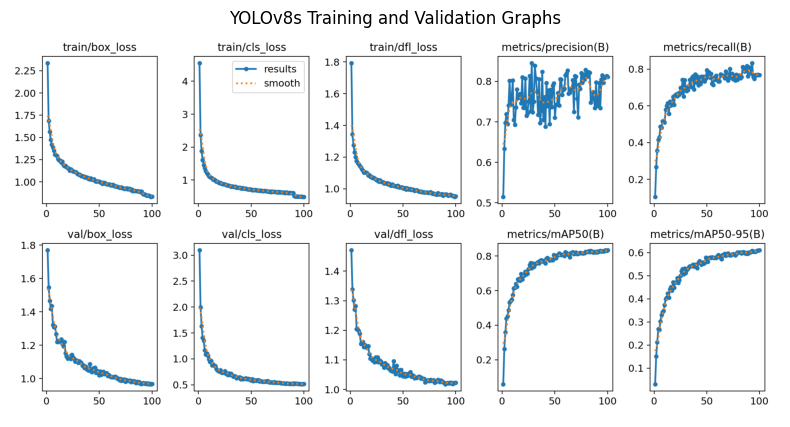

In [ ]:
# Ploteamos los resultados del entrenamiento y validación.
# Plot the training and validation results.
plt.figure(figsize=(10, 5))
img = mpimg.imread('runs/detect/trainv8/results.png')
plt.imshow(img)
plt.title('YOLOv8s Training and Validation Graphs')
plt.axis('off')
plt.show()

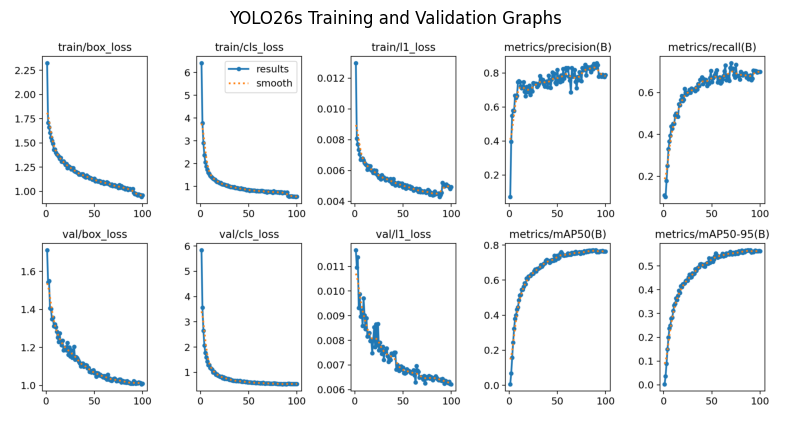

In [ ]:
# Ploteamos los resultados del entrenamiento y validación.
# Plot the training and validation results.
plt.figure(figsize=(10, 5))
img = mpimg.imread('runs/detect/trainv26/results.png')
plt.imshow(img)
plt.title('YOLO26s Training and Validation Graphs')
plt.axis('off')
plt.show()

In [ ]:
# Testeamos el modelo entrenado.
# Model Testing.
model = YOLO('runs/detect/trainv8/weights/best.pt')
metrics_Yolov8 = model.val(data='data.yaml', split='test')

Ultralytics 8.4.160 🚀 Python-3.13.15 torch-2.11.0+cpu CPU (AMD EPYC 7B12)
Model summary (fused): 73 layers, 11,146,482 parameters, 0 gradients, 28.5 GFLOPs
WARNING ⚠️ val: Slow image access detected (ping: 0.6±0.3 ms, read: 18.2±1.9 MB/s, size: 27.8 KB). Use local storage instead of remote/mounted storage for better performance. See https://docs.ultralytics.com/guides/model-training-tips
val: Scanning /content/drive/MyDrive/Trabajo de Grado/Dataset - Yolo/test/labels.cache... 400 images, 0 backgrounds, 1 corrupt: 100% ━━━━━━━━━━━━ 400/400 64.5Mit/s 0.0s
val: /content/drive/MyDrive/Trabajo de Grado/Dataset - Yolo/test/images/BRA462_jpg.rf.3d37951afd39877a7ad4953a2aba63a0.jpg: ignoring corrupt image/label: labels mix segment and detection rows
WARNING ⚠️ Box and segment counts should be equal, but got len(segments) = 31, len(boxes) = 6609. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect

In [ ]:
# Testeamos el modelo entrenado.
# Model Testing.
model = YOLO('runs/detect/trainv26/weights/best.pt')
metrics_Yolo26 = model.val(data='data.yaml', split='test')

Ultralytics 8.4.160 🚀 Python-3.13.15 torch-2.11.0+cpu CPU (AMD EPYC 7B12)
YOLO26s summary (fused): 120 layers, 9,486,078 parameters, 0 gradients, 20.9 GFLOPs
WARNING ⚠️ val: Slow image access detected (ping: 0.6±0.2 ms, read: 26.7±16.0 MB/s, size: 36.1 KB). Use local storage instead of remote/mounted storage for better performance. See https://docs.ultralytics.com/guides/model-training-tips
val: Scanning /content/drive/MyDrive/Trabajo de Grado/Dataset - Yolo/test/labels.cache... 400 images, 0 backgrounds, 1 corrupt: 100% ━━━━━━━━━━━━ 400/400 79.9Mit/s 0.0s
val: /content/drive/MyDrive/Trabajo de Grado/Dataset - Yolo/test/images/BRA462_jpg.rf.3d37951afd39877a7ad4953a2aba63a0.jpg: ignoring corrupt image/label: labels mix segment and detection rows
WARNING ⚠️ Box and segment counts should be equal, but got len(segments) = 31, len(boxes) = 6609. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a det

In [ ]:
# Mostramos metricas.
# Show metrics.
print("------------------------------------------Yolov8s Metrics------------------------------------------")
print("mAP50:", metrics_Yolov8.box.map50)         # mAP@0.5
print("mAP50-95:", metrics_Yolov8.box.map)        # mAP@[.5:.95]
print("F1 Score", metrics_Yolov8.box.f1)
print("Avg F1 Score", statistics.mean(metrics_Yolov8.box.f1))
print("Precision:", metrics_Yolov8.box.p)      # Precisión
print("Avg Precision", statistics.mean(metrics_Yolov8.box.p)) #Precisión Promedio
print("Recall:", metrics_Yolov8.box.r)          # Recall
print("Avg Recall", statistics.mean(metrics_Yolov8.box.r)) #Recall Promedio
print("------------------------------------------------------------------------------------")
print("------------------------------------------Yolo26s Metrics------------------------------------------")
print("mAP50:", metrics_Yolo26.box.map50)         # mAP@0.5
print("mAP50-95:", metrics_Yolo26.box.map)        # mAP@[.5:.95]
print("F1 Score", metrics_Yolo26.box.f1)
print("Avg F1 Score", statistics.mean(metrics_Yolo26.box.f1))
print("Precision:", metrics_Yolo26.box.p)      # Precisión
print("Avg Precision", statistics.mean(metrics_Yolo26.box.p)) #Precisión Promedio
print("Recall:", metrics_Yolo26.box.r)          # Recall
print("Avg Recall", statistics.mean(metrics_Yolo26.box.r)) #Recall Promedio

------------------------------------------Yolov8s Metrics------------------------------------------
mAP50: 0.8474729238064466
mAP50-95: 0.6035871556519458
F1 Score [    0.93576     0.90149     0.96673     0.92586     0.90121     0.86439     0.95139     0.92065      0.8511     0.78237       0.886     0.89255     0.93379     0.93228     0.96267      0.8579      0.8322     0.93757     0.93165     0.95075     0.91716     0.89207     0.92042     0.94657     0.92177     0.86889
     0.35368     0.89438     0.69652     0.62969     0.93311     0.85351     0.86571     0.83313     0.66055     0.53935     0.96267     0.73215     0.47666           0     0.90446     0.19197     0.66991     0.86419     0.83719     0.79965     0.62458    0.066967]
Avg F1 Score 0.7911500693932948
Precision: [    0.91777      0.8785     0.95847     0.89539     0.87294     0.81389     0.95499     0.87929     0.79053     0.77627     0.83319     0.84741     0.89752     0.90503      0.9519     0.78486     0.76729      0.90

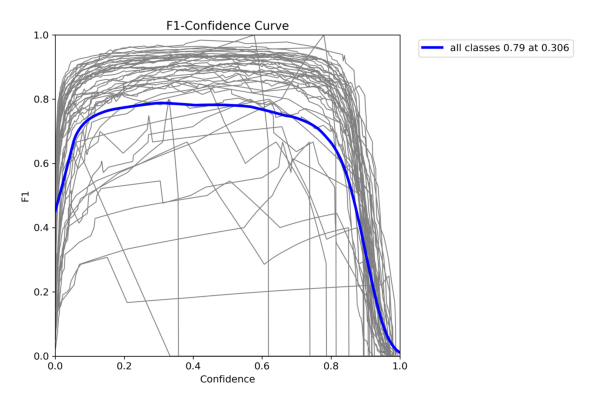

In [ ]:
# Ruta a la imagen generada con las métricas (F1-Score).
# Route to the metric image (F1-Score).
img_path = 'runs/detect/val-3/BoxF1_curve.png'

# Mostrar la imagen.
# Show the image.
img = mpimg.imread(img_path)
plt.figure(figsize=(10, 5))
plt.imshow(img)
plt.axis('off')  # Quitar ejes
plt.show()

/content/drive/MyDrive/Trabajo de Grado/Dataset - Yolo

image 1/1 /content/drive/MyDrive/Trabajo de Grado/Dataset - Yolo/test/images/mmm2_jpg.rf.f57c9402b4cd7b1ee19e94630946888a.jpg: 640x640 4 As, 2 Bs, 2 Is, 2 Ls, 1 M, 1 N, 2 Rs, 1 S, 1 T, 1 V, 1 e_tilde, 1 u_tilde, 1167.1ms
Speed: 7.0ms preprocess, 1167.1ms inference, 1.8ms postprocess per image at shape (1, 3, 640, 640)
Clase: T, Confianza: 0.93, Coordenadas: [37.770442962646484, 301.40802001953125, 90.93576049804688, 358.3143310546875]
Clase: M, Confianza: 0.91, Coordenadas: [142.71377563476562, 296.926025390625, 198.48110961914062, 353.46435546875]
Clase: A, Confianza: 0.91, Coordenadas: [93.08143615722656, 299.58892822265625, 142.1947021484375, 360.7640380859375]
Clase: N, Confianza: 0.90, Coordenadas: [343.9062194824219, 301.58587646484375, 401.6674499511719, 358.20831298828125]
Clase: I, Confianza: 0.90, Coordenadas: [215.605224609375, 401.954833984375, 260.3392639160156, 458.1114501953125]
Clase: R, Confianza: 0.89, Coordenada

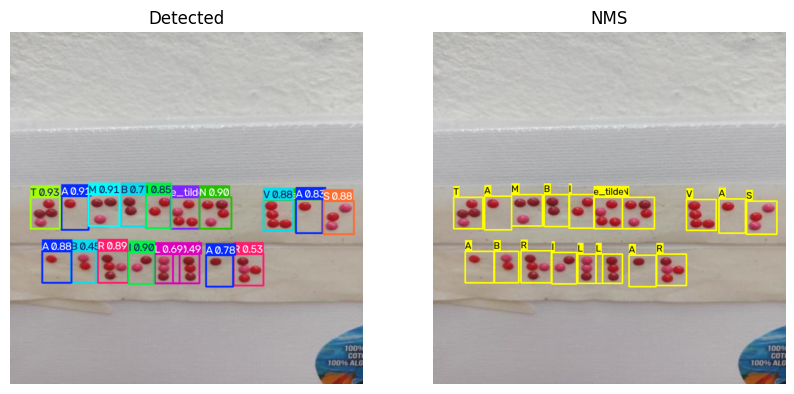

---------------------
también vas
abrill ar
---------------------
['también vas', 'abrill ar']
---------------------


In [ ]:
# Carga tu modelo entrenado.
# Load the trained model.
yolo_trained = YOLO('runs/detect/trainv8/weights/best.pt')

# Haz una predicción sobre una imagen.
# Make a prediction on an image.
print(os.getcwd())
results = yolo_trained.predict(source='/content/drive/MyDrive/Trabajo de Grado/Dataset - Yolo/test/images/mmm2_jpg.rf.f57c9402b4cd7b1ee19e94630946888a.jpg', save=False, conf=0.25)

# Mostrar resultados en texto.
# Show results on text.
for box in results[0].boxes:
    cls = int(box.cls[0])
    conf = float(box.conf[0])
    coords = box.xyxy[0].tolist()
    print(f"Clase: {results[0].names[cls]}, Confianza: {conf:.2f}, Coordenadas: {coords}")

# Mostrar la imagen
nms_results, text_results = nms_Yolo(results, results[0].orig_img, iou=0.3)
nms_results = cv2.cvtColor(nms_results, cv2.COLOR_BGR2RGB)
og_results = cv2.cvtColor(results[0].plot(), cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10, 10))
plt.subplot(1, 2, 1)
plt.title("Detected")
plt.imshow(og_results)
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title("NMS")
plt.imshow(nms_results)
plt.axis('off')

plt.show()

print("---------------------")
for line in text_results:
    print(line)
print("---------------------")
print(text_results)
print("---------------------")



/content/drive/MyDrive/Trabajo de Grado/Dataset - Yolo

image 1/1 /content/drive/MyDrive/Trabajo de Grado/Dataset - Yolo/test/images/0000986_jpg.rf.ecd09af4e1d5b6596401ad1b90ef49e7.jpg: 640x640 1 C, 1 D, 1 H, 3 Os, 1 T, 1 U, 1 W, 793.0ms
Speed: 6.5ms preprocess, 793.0ms inference, 1.7ms postprocess per image at shape (1, 3, 640, 640)


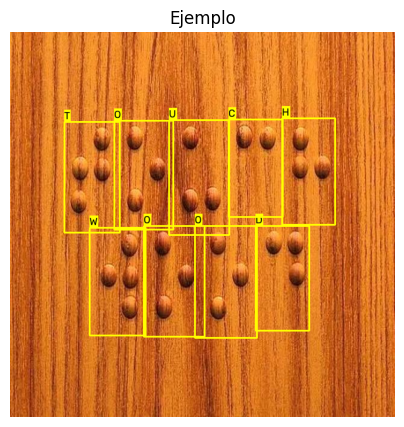

------------------------------------
Usando tódo el umbral
------------------------------------
twoouo cdh
------------------------------------
------------------------------------
Usando 90% del valor del umbral
------------------------------------
touch
wood
------------------------------------


In [ ]:
# Carga tu modelo entrenado.
# Load the trained model.
yolo_trained = YOLO('runs/detect/trainv8/weights/best.pt')

# Haz una predicción sobre una imagen.
# Make a prediction on an image.
print(os.getcwd())
results = yolo_trained.predict(source='/content/drive/MyDrive/Trabajo de Grado/Dataset - Yolo/test/images/0000986_jpg.rf.ecd09af4e1d5b6596401ad1b90ef49e7.jpg', save=False, conf=0.25)

# Mostrar la imagen
nms_results1, text_results1 = nms_Yolo(results, results[0].orig_img, 0.9, iou=0.3)
nms_results1 = cv2.cvtColor(nms_results1, cv2.COLOR_BGR2RGB)

nms_results2, text_results2 = nms_Yolo(results, results[0].orig_img, 1, iou=0.3)
nms_results2 = cv2.cvtColor(nms_results2, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(5, 5))
plt.title("Ejemplo")
plt.imshow(nms_results1)
plt.axis('off')

plt.show()

print("------------------------------------")
print("Usando tódo el umbral")
print("------------------------------------")
for line in text_results2:
    print(line)
print("------------------------------------")
print("------------------------------------")
print("Usando 90% del valor del umbral")
print("------------------------------------")
for line in text_results1:
    print(line)
print("------------------------------------")

In [ ]:
text_sample = ["Cambió", "todo en mí", "luego de que llegaras"]
play_text("".join(text_sample), lan="es")

In [ ]:
import subprocess
from IPython.display import Audio
!apt-get install espeak-ng
!apt-get install festival
!apt-get install festvox-ellpc11k

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
espeak-ng is already the newest version (1.51+dfsg-12build1).
0 upgraded, 0 newly installed, 0 to remove and 11 not upgraded.
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
festival is already the newest version (1:2.5.0-10).
0 upgraded, 0 newly installed, 0 to remove and 11 not upgraded.
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
festvox-ellpc11k is already the newest version (1.95-1).
0 upgraded, 0 newly installed, 0 to remove and 11 not upgraded.


In [ ]:
#@title Definimos el modulo de Text-to-Speech usando eSpeak

def text_to_speech_os_system_save(text, output_filename='espeak_output.wav'):
    os.system(f"espeak-ng -v es -w {output_filename} '{text}'")
    return Audio(output_filename, autoplay=True)

text_to_speech_os_system_save(" ".join(text_sample))

In [ ]:
#@title Definimos el modulo de Text-to-Speech usando FestivalTTS
def festival_play_text(input_text, lan="en", file_name="festival_output.wav"):
    if lan == "es":
        voice = "(voice_el_diphone)"
    elif lan == "en":
        voice = "(voice_kal_diphone)"

    # Escribir el texto a un archivo temporal para que festival lo lea
    temp_text_file = "temp_festival_input.txt"
    with open(temp_text_file, "w", encoding="latin-1") as f:
        f.write(input_text)

    # Construir el comando para festival (text2wave) para generar el archivo WAV
    command = [
        'text2wave',
        '-eval', voice, # Specify the voice
        '-o', file_name,
        temp_text_file
    ]

    subprocess.run(command, check=True, capture_output=True, text=True)
    print(f"Audio guardado como: {file_name}")

    # Limpiar el archivo de texto temporal
    os.remove(temp_text_file)

    return Audio(file_name, autoplay=True)
# Speak text directly using the festivaltts function
festival_play_text("".join(text_sample), lan="es")

Audio guardado como: festival_output.wav


## Entrenamos un Transformer

In [ ]:
# Cargamos un modelo pre-entrenado rt-detr-l
# Load a pretrained model rt-detr-l
model = RTDETR("rtdetr-l.pt")

# Mostrar la información del modelo
# Show model information
model.info()

rt-detr-l summary: 449 layers, 32,970,476 parameters, 0 gradients, 110.2 GFLOPs


(449, 32970476, 0, 110.243408)

In [8]:
#Nos posicionamos en el directorio en donde vamos a entrenar
#Go to the folder where we will train the model
os.chdir('/content/drive/MyDrive/Trabajo de Grado')
print(os.getcwd())

/content/drive/MyDrive/Trabajo de Grado


In [ ]:
#Entrenamos el modelo
#Model training
model.train(data="Dataset - Yolo/data.yaml", epochs=50, imgsz=640, batch=8)

Ultralytics 8.4.115 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (NVIDIA L4, 22563MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=Dataset - Yolo/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=rtdetr-l.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train-6, nbs=64, nms=False, opset=No

/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:869: UserWarning: grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


       1/50      16.8G      1.461      0.739     0.7172         78        640: 100% ━━━━━━━━━━━━ 401/401 2.2it/s 3:01
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 25/25 3.7it/s 6.8s
                   all        400       6374      0.692      0.115     0.0272     0.0131

      Epoch    GPU_mem  giou_loss   cls_loss    l1_loss  Instances       Size
       2/50      6.51G     0.8173     0.9284     0.2653        176        640: 0% ──────────── 0/401  0.5s

/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:869: UserWarning: grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


       2/50      14.2G     0.8647     0.8883     0.3493        219        640: 100% ━━━━━━━━━━━━ 401/401 2.4it/s 2:48
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 25/25 4.5it/s 5.6s
                   all        400       6374      0.707      0.232      0.194      0.103

      Epoch    GPU_mem  giou_loss   cls_loss    l1_loss  Instances       Size
       3/50      6.39G      0.667     0.8562     0.1864        110        640: 0% ──────────── 0/401  0.4s

...

/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:869: UserWarning: grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


      49/50      15.1G     0.3135      0.394    0.08997         70        640: 100% ━━━━━━━━━━━━ 401/401 2.4it/s 2:45
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 25/25 4.5it/s 5.6s
                   all        400       6374      0.801      0.847      0.864      0.631

      Epoch    GPU_mem  giou_loss   cls_loss    l1_loss  Instances       Size
      50/50      6.75G     0.2846     0.3734    0.08165         79        640: 0% ──────────── 0/401  0.4s

/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:869: UserWarning: grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


      50/50      17.1G     0.3105     0.3915    0.09121         28        640: 100% ━━━━━━━━━━━━ 401/401 2.4it/s 2:45
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 25/25 4.5it/s 5.6s
                   all        400       6374       0.81      0.848      0.869      0.635

50 epochs completed in 2.416 hours.
Optimizer stripped from /content/drive/MyDrive/Trabajo de Grado/runs/detect/train-6/weights/last.pt, 66.4MB
Optimizer stripped from /content/drive/MyDrive/Trabajo de Grado/runs/detect/train-6/weights/best.pt, 66.4MB

Validating /content/drive/MyDrive/Trabajo de Grado/runs/detect/train-6/weights/best.pt...
Ultralytics 8.4.115 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (NVIDIA L4, 22563MiB)
rt-detr-l summary: 315 layers, 32,094,710 parameters, 0 gradients, 105.6 GFLOPs
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 25/25 4.2it/s 5.9s
                   all        

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 43, 44, 45, 47, 48, 49, 50, 51, 52])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7b8a2d52ef30>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.

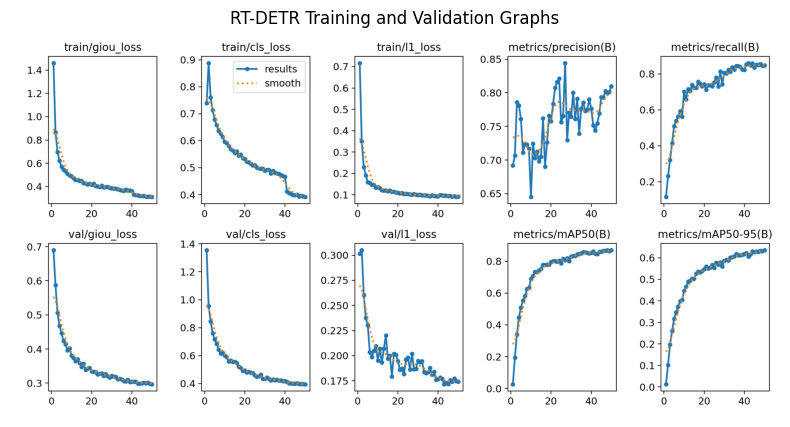

In [ ]:
# Ploteamos los resultados del entrenamiento y validación.
# Plot the training and validation results.
plt.figure(figsize=(10, 5))
img = mpimg.imread('runs/detect/train_trans/results.png')
plt.imshow(img)
plt.title('RT-DETR Training and Validation Graphs')
plt.axis('off')
plt.show()

In [ ]:
# Testeamos el modelo entrenado.
# Model Testing.
model = RTDETR('runs/detect/train_trans/weights/best.pt')
metrics_Trans = model.val(data="Dataset - Yolo/data.yaml", split='test')

Ultralytics 8.4.160 🚀 Python-3.13.15 torch-2.11.0+cpu CPU (AMD EPYC 7B12)
rt-detr-l summary (fused): 315 layers, 32,094,710 parameters, 0 gradients, 105.6 GFLOPs
WARNING ⚠️ val: Slow image access detected (ping: 1.0±1.2 ms, read: 16.0±7.7 MB/s, size: 20.4 KB). Use local storage instead of remote/mounted storage for better performance. See https://docs.ultralytics.com/guides/model-training-tips
val: Scanning /content/drive/MyDrive/Trabajo de Grado/Dataset - Yolo/test/labels.cache... 400 images, 0 backgrounds, 1 corrupt: 100% ━━━━━━━━━━━━ 400/400 88.3Mit/s 0.0s
val: /content/drive/MyDrive/Trabajo de Grado/Dataset - Yolo/test/images/BRA462_jpg.rf.3d37951afd39877a7ad4953a2aba63a0.jpg: ignoring corrupt image/label: labels mix segment and detection rows
WARNING ⚠️ Box and segment counts should be equal, but got len(segments) = 31, len(boxes) = 6609. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a 

In [ ]:
# Mostramos metricas.
# Show metrics.
print("------------------------------------------Real-Time Detection Transformer (RT-DETR) Metrics------------------------------------------")
print("mAP50:", metrics_Trans.box.map50)         # mAP@0.5
print("mAP50-95:", metrics_Trans.box.map)        # mAP@[.5:.95]
print("F1 Score", metrics_Trans.box.f1)
print("Avg F1 Score", statistics.mean(metrics_Trans.box.f1))
print("Precision:", metrics_Trans.box.p)      # Precisión
print("Avg Precision", statistics.mean(metrics_Trans.box.p)) #Precisión Promedio
print("Recall:", metrics_Trans.box.r)          # Recall
print("Avg Recall", statistics.mean(metrics_Trans.box.r))

------------------------------------------Real-Time Detection Transformer (RT-DETR) Metrics------------------------------------------
mAP50: 0.8776481091157864
mAP50-95: 0.6361931589426378
F1 Score [     0.9207     0.89534     0.93145     0.89448     0.90932     0.90746     0.95534     0.90184     0.91095     0.94452      0.8524     0.91618     0.90527     0.93098     0.93838      0.8555     0.86804     0.93218     0.90059     0.91834     0.92882     0.90747     0.89388     0.93309      0.9104     0.84757
     0.54633     0.89871     0.72559      0.5844     0.89398      0.8432      0.8093     0.76193     0.95925     0.77061     0.90797     0.91174     0.66363           0     0.88005     0.44012     0.82698      0.8139     0.81284     0.65901     0.63799      0.8884]
Avg F1 Score 0.8301344699591754
Precision: [    0.89549     0.86195     0.89429     0.83326     0.85033     0.89378     0.95416     0.84888     0.89227      0.9497     0.81229     0.89167     0.89212     0.89109     0.89882

/content/drive/MyDrive/Trabajo de Grado

image 1/1 /content/drive/MyDrive/Trabajo de Grado/Dataset - Yolo/test/images/15_jpg.rf.4f7c6118ffabee195651de3f42c4aeb6.jpg: 640x640 60 As, 7 Bs, 1 C, 6 Ds, 2 Es, 3 Fs, 27 Gs, 4 Hs, 14 Is, 11 Ks, 8 Ls, 7 Ms, 35 Ns, 13 Os, 1 P, 5 Rs, 7 Ss, 8 Ts, 5 Us, 4 Ws, 4 Ys, 2 apostrophes, 13 capitals, 1 colon, 2 commas, 42 hyphens, 1 letter_sign, 3 number_signs, 1 period, 1 semicolon, 1976.3ms
Speed: 4.9ms preprocess, 1976.3ms inference, 0.4ms postprocess per image at shape (1, 3, 640, 640)
Clase: Y, Confianza: 0.91, Coordenadas: [478.1025390625, 151.38587951660156, 495.5736083984375, 172.07241821289062]
Clase: G, Confianza: 0.91, Coordenadas: [420.2587585449219, 163.80984497070312, 437.674072265625, 184.89834594726562]
Clase: Y, Confianza: 0.91, Coordenadas: [426.7044372558594, 404.032958984375, 444.4382019042969, 426.46368408203125]
Clase: hyphen, Confianza: 0.90, Coordenadas: [77.89444732666016, 533.6649780273438, 95.99883270263672, 556.8494262695312]
Cl

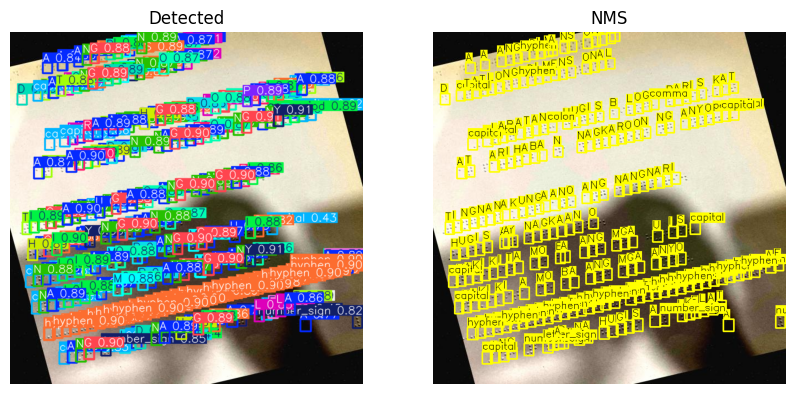

---------------------
o na la
-dima ns
a a ang imens onal
ong-d t
dTatl log,pariska
gisb yo.CAPITAL
tan:hu nngan
 CAPITALlara n nagkaroo
ihaba
atar ari
n
g nang
aano an
nakung
tingna nagkaano uis
aay ga
hugis mobaangm anyo f
ta ga -a
Nakiki mo ba ang m -----------
ia ---
Nakik --------- - lkflat
--- a 
------ Adnahugis a

Ang 
---------------------


In [26]:
# Carga tu modelo entrenado.
# Load the trained model.
trans_trained = RTDETR('runs/detect/train_trans/weights/best.pt')

images_path = 'Dataset - Yolo/test/'
images_jpg = sorted(os.listdir(f'{images_path}/images'))
indxs = random.choice(range(len(images_jpg)))

# Haz una predicción sobre una imagen.
# Make a prediction on an image.
print(os.getcwd())
results = trans_trained.predict(source=f'{images_path}/images/{images_jpg[indxs]}', save=False, conf=0.25)
#results = yolo_trained.predict(source='/content/drive/MyDrive/Trabajo de Grado/Dataset - Yolo/test/images/BRA450_png_jpg.rf.80e92a8f79b8a841db063566970860af.jpg', save=False, conf=0.25)

# Mostrar resultados en texto.
# Show results on text.
for box in results[0].boxes:
    cls = int(box.cls[0])
    conf = float(box.conf[0])
    coords = box.xyxy[0].tolist()
    print(f"Clase: {results[0].names[cls]}, Confianza: {conf:.2f}, Coordenadas: {coords}")

# Mostrar la imagen
nms_results, text_results = nms_Yolo(results, results[0].orig_img, iou=0.5)
nms_results = cv2.cvtColor(nms_results, cv2.COLOR_BGR2RGB)
og_results = cv2.cvtColor(results[0].plot(), cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10, 10))
plt.subplot(1, 2, 1)
plt.title("Detected")
plt.imshow(og_results)
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title("NMS")
plt.imshow(nms_results)
plt.axis('off')

plt.show()

print("---------------------")
for line in text_results:
    print(line)
print("---------------------")


image 1/1 /content/drive/MyDrive/Trabajo de Grado/Dataset - Yolo/test/images/IMG_111_png.rf.1008c6a3193f017f07317f17b4017707.jpg: 640x640 1 A, 1 E, 1 H, 1 O, 1 P, 3 Rs, 2 Ts, 1 W, 1 Y, 4180.0ms
Speed: 25.2ms preprocess, 4180.0ms inference, 0.5ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 /content/drive/MyDrive/Trabajo de Grado/Dataset - Yolo/test/images/mmm2_jpg.rf.f57c9402b4cd7b1ee19e94630946888a.jpg: 640x640 4 As, 2 Bs, 2 Is, 2 Ls, 1 M, 1 N, 2 Rs, 1 S, 1 T, 1 V, 1 e_tilde, 1 u_tilde, 563.1ms
Speed: 5.2ms preprocess, 563.1ms inference, 1.2ms postprocess per image at shape (1, 3, 640, 640)


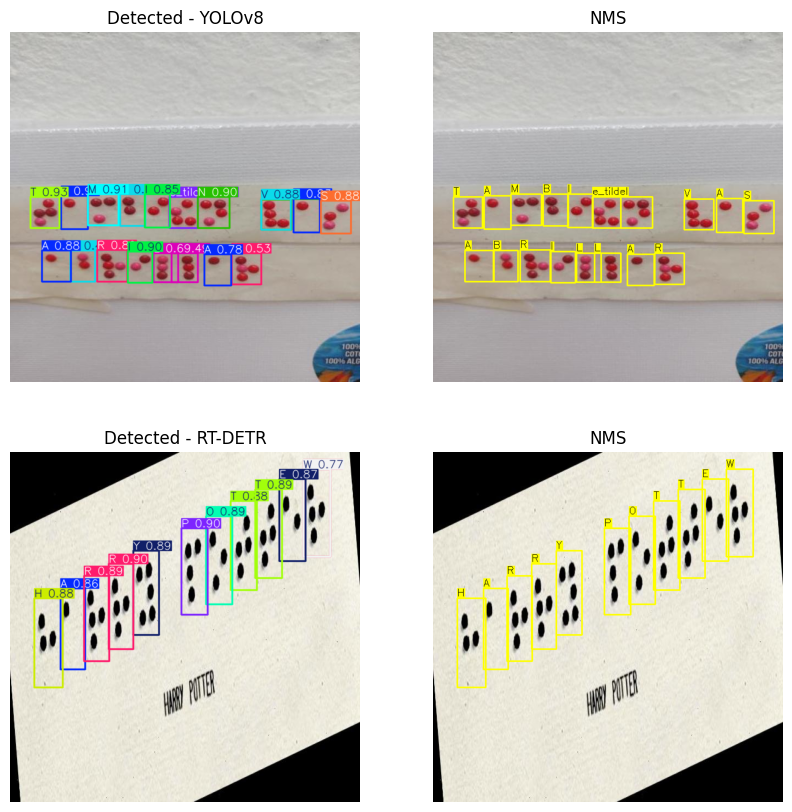

In [13]:
# Carga tu modelo entrenado.
# Load the trained model.
trans_trained = RTDETR('runs/detect/train_trans/weights/best.pt')

# Haz una predicción sobre una imagen.
trans_results = trans_trained.predict(source='/content/drive/MyDrive/Trabajo de Grado/Dataset - Yolo/test/images/IMG_111_png.rf.1008c6a3193f017f07317f17b4017707.jpg', save=False, conf=0.25)

# Mostrar la imagen
nms_results_trans, text_results = nms_Yolo(trans_results, trans_results[0].orig_img, iou=0.5)
nms_results_trans = cv2.cvtColor(nms_results_trans, cv2.COLOR_BGR2RGB)
og_results_trans = cv2.cvtColor(trans_results[0].plot(), cv2.COLOR_BGR2RGB)

##########################################################################
yolo_trained = YOLO('Dataset - Yolo/runs/detect/trainv8/weights/best.pt')

# Haz una predicción sobre una imagen.
# Make a prediction on an image.
results = yolo_trained.predict(source='/content/drive/MyDrive/Trabajo de Grado/Dataset - Yolo/test/images/mmm2_jpg.rf.f57c9402b4cd7b1ee19e94630946888a.jpg', save=False, conf=0.25)

# Mostrar la imagen
nms_results, text_results = nms_Yolo(results, results[0].orig_img, iou=0.3)
nms_results = cv2.cvtColor(nms_results, cv2.COLOR_BGR2RGB)
og_results = cv2.cvtColor(results[0].plot(), cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10, 10))
plt.subplot(2, 2, 1)
plt.title("Detected - YOLOv8")
plt.imshow(og_results)
plt.axis('off')

plt.subplot(2, 2, 2)
plt.title("NMS")
plt.imshow(nms_results)
plt.axis('off')

plt.subplot(2, 2, 3)
plt.title("Detected - RT-DETR")
plt.imshow(og_results_trans)
plt.axis('off')

plt.subplot(2, 2, 4)
plt.title("NMS")
plt.imshow(nms_results_trans)
plt.axis('off')

plt.show()


In [ ]:
play_text("".join(text_results))

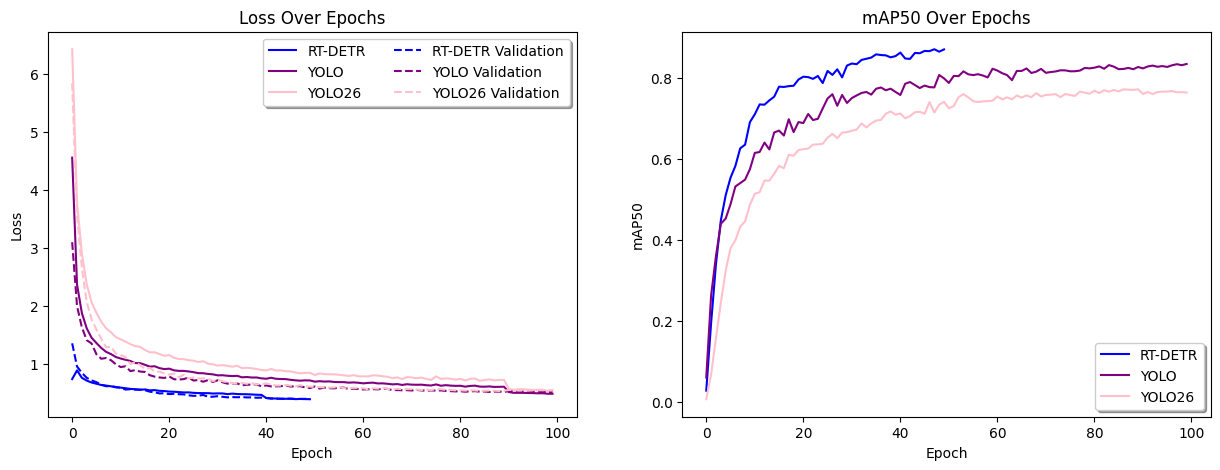

In [ ]:
#@title Visualizamos la perdida de clases en los tres modelos en una misma grafica

RT_DETR = pd.read_csv('runs/detect/train_trans/results.csv')
YOLO = pd.read_csv('Dataset - Yolo/runs/detect/trainv8/results.csv')
YOLO_26 = pd.read_csv('Dataset - Yolo/runs/detect/trainv26/results.csv')

plt.figure(figsize=(15, 5))
plt.subplot(1, 2, 1)
plt.plot(RT_DETR['train/cls_loss'], label='RT-DETR', color="blue")
plt.plot(YOLO['train/cls_loss'], label='YOLO', color="purple")
plt.plot(YOLO_26['train/cls_loss'], label='YOLO26', color="pink")
plt.plot(RT_DETR['val/cls_loss'], label='RT-DETR Validation', linestyle="--", color="blue")
plt.plot(YOLO['val/cls_loss'], label='YOLO Validation', linestyle="--", color="purple")
plt.plot(YOLO_26['val/cls_loss'], label='YOLO26 Validation', linestyle="--", color="pink")
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss Over Epochs')
plt.legend(ncols=2, shadow=True)

plt.subplot(1, 2, 2)
plt.plot(RT_DETR['metrics/mAP50(B)'], label='RT-DETR', color="blue")
plt.plot(YOLO['metrics/mAP50(B)'], label='YOLO', color="purple")
plt.plot(YOLO_26['metrics/mAP50(B)'], label='YOLO26', color="pink")
plt.xlabel('Epoch')
plt.ylabel('mAP50')
plt.title('mAP50 Over Epochs')
plt.legend(shadow=True)
plt.show()

# Entrenando modelos en el framework Pytorch

In [ ]:
#Librerías necesarias
#Necessary libraries
import torch
import torchvision
import torch.nn as nn
from functools import partial
from torch.utils.data import DataLoader
from torchvision import transforms
from torchvision.models.detection import _utils as det_utils
from torchvision.models.detection import FasterRCNN
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.models.detection.ssdlite import SSDLiteHead
from torchvision.models.detection import retinanet_resnet50_fpn_v2
from torchvision.models.detection.retinanet import RetinaNet_ResNet50_FPN_V2_Weights
from torchvision.datasets import CocoDetection
from torchvision.transforms import functional as F
from torchvision.utils import draw_bounding_boxes
from torchvision.ops import nms
from torchmetrics.detection import MeanAveragePrecision
from PIL import Image
from engine import train_one_epoch, evaluate

In [ ]:
#@title Declaramos toda la logica de preprocesamiento del dataset

# Define las transformaciones
# Define transformations
class CocoTransform:
    def __call__(self, image, target):
        image = F.to_tensor(image)

        boxes = []
        labels = []

        if target:

            image_id = target[0]['image_id']

            for annotation in target:
                x, y, w, h = annotation['bbox']
                # Convert [x, y, width, height] to [x_min, y_min, x_max, y_max]
                # Filter out invalid boxes (width or height is 0 or less)
                if w > 0 and h > 0:
                    boxes.append([x, y, x + w, y + h])
                    labels.append(annotation['category_id'])

        if not boxes:
            boxes_tensor = torch.zeros((0, 4), dtype=torch.float32)
            labels_tensor = torch.zeros((0,), dtype=torch.int64)
        else:
            boxes_tensor = torch.as_tensor(boxes, dtype=torch.float32)
            labels_tensor = torch.as_tensor(labels, dtype=torch.int64)

        # Create a single dictionary for the target, as expected by the model for evaluation
        processed_target = {
            "boxes": boxes_tensor,
            "labels": labels_tensor,
            "image_id": image_id
        }
        return image, processed_target

In [ ]:
#@title Declaramos la logica de entrenamiento, validación y testeo

def training_loop(model, optimizer, train_loader, device, n_epochs, print_freq, save_dir):
    # Training loop
    best_val_map = float('-inf') # Initialize with a very low value for mAP (higher is better)

    # Directory where the models will be saved
    model_save_dir = save_dir

    # Create directory if it doesn't exist
    os.makedirs(model_save_dir, exist_ok=True) # Added to ensure directory exists

    training_loss = []
    validation_map = []

    for epoch in range(num_epochs):
        print(f"Epoch [{epoch}]")
        print("-------------------------------------------------------------------------------------------------------------------------------------------------")
        current_loss = train_one_epoch(model, optimizer, train_loader, device, epoch, print_freq=100)
        print("-----------------------------------------------------------------------")
        print(current_loss)
        print("-----------------------------------------------------------------------")
        training_loss.append(current_loss)
        lr_scheduler.step()

        # Validate the model and get mAP
        coco_evaluator_results = evaluate(model, val_loader, device)

        # Extract mAP from the CocoEvaluator results
        current_val_map = coco_evaluator_results.coco_eval['bbox'].stats[0] if coco_evaluator_results and 'bbox' in coco_evaluator_results.coco_eval else 0.0
        validation_map.append(current_val_map)
        print("-----------------------------------------------------------------------")
        print(f"Epoch [{epoch}] Validation mAP@0.5:0.95: {current_val_map:.4f}")

        # Save the best model based on validation mAP
        if current_val_map > best_val_map:
            best_val_map = current_val_map
            best_model_path = os.path.join(model_save_dir, f"best_{save_dir}.pth")
            torch.save(model.state_dict(), best_model_path)
            print(f"Model saved: {best_model_path} with improved validation mAP: {best_val_map:.4f}")
        print("-----------------------------------------------------------------------")

        # Save the last model trained (regardless of performance)
        last_model_path = os.path.join(model_save_dir, f"last_{save_dir}.pth")
        torch.save(model.state_dict(), last_model_path)
        print(f"Last model saved: {last_model_path}")


    print("Training Completed")

    return training_loss, validation_map


def test_loop(model, test_loader, device):
    # Test loop
    test_map = []

    # Validate the model and get mAP
    coco_evaluator_results = evaluate(model, test_loader, device)

    # Extract mAP from the CocoEvaluator results
    current_val_map = coco_evaluator_results.coco_eval['bbox'].stats[0] if coco_evaluator_results and 'bbox' in coco_evaluator_results.coco_eval else 0.0
    test_map.append(current_val_map)

    print("Testing Completed")

    return test_map

In [ ]:
#@title Declaramos la logica de postprocesamiento

def nms_Pytorch(pred, dataset, sample_idx, label_maps, iou_threshold=0.3):
    # Obtenemos las cajas, los puntajes y las clases.
    # Get the boxes, scores and classes.
    boxes = pred["boxes"]
    scores = pred["scores"]
    classes = pred["labels"]

    # Aplicar NMS manualmente con IoU
    # Apply NMS manually with IoU
    keep = nms(boxes, scores, iou_threshold=0.3)

    # Filtrar resultados
    # Filter the results
    filtered_boxes = boxes[keep]
    filtered_scores = scores[keep]
    filtered_classes = classes[keep]

    #Obtenemos la imagen
    sample = test_dataset[sample_idx]
    image = sample[0]
    image = (255.0 * (image - image.min()) / (image.max() - image.min())).to(torch.uint8)
    image = image[:3, ...]
    image = image.permute(1, 2, 0).numpy().copy()

    # Usa las predicciones filtradas con NMS
    # Use filtered predictions with NMS
    for i in range(len(keep)):
        cls = int(filtered_classes[i])
        conf = float(filtered_scores[i])
        x1, y1, x2, y2 = map(int, filtered_boxes[i])
        label = f"{labels_map[cls]}"

        # Dibujar rectángulo
        # Draw the rectangle
        cv2.rectangle(image, (x1, y1), (x2, y2), (0, 255, 255), 2)

        # Etiqueta con fondo
        # Label with background
        (tw, th), _ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.6, 1)
        cv2.rectangle(image, (x1, y1 - th - 4), (x1 + tw, y1), (0, 255, 255), -1)
        cv2.putText(image, label, (x1, y1 - 4), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 0, 0), 1)

    text = spatial_organization_pytorch(labels_map, keep, filtered_boxes, filtered_classes)

    return image, text


def spatial_organization_pytorch(labels_map, keep, filtered_boxes, filtered_classes):
    # Declaramos un diccionario para caracteres especiales
    special_characters = {
        'a_tilde': 'á', 'ampersand': '&', 'apostrophe': "'", 'asterisk': '*', 'close_parenthesis': ')', 'closequotation': '"', 'colon': ':', 'comma': ',', 'e_tilde': 'é', 'exclamation_mark': '!', 'greaterthan': '>', 'hyphen': '-', 'i_tilde': 'í', 'lessthan': '<', 'minus': '-', 'n_tilde': 'ñ', 'o_tilde': 'ó', 'open_parenthesis': '(', 'parentheses': '()', 'period': '.', 'question_mark': '?', 'semicolon': ';', 'slash': '/', 'u_dieresis': 'ü', 'u_tilde': 'ú'
    }
    numbers = {
        'j': '0', 'a': '1', 'b': '2', 'c': '3', 'd': '4', 'e': '5', 'f': '6', 'g': '7', 'h': '8', 'i': '9'
    }

    # Agrupar por líneas (por y1)
    line_groups = defaultdict(list)
    lenght = len(filtered_boxes)
    if lenght == 0:
      return []
    else:
      x1, y1, x2, y2 = filtered_boxes[0].tolist()
    y_threshold = np.abs(y1-y2) # tolerancia vertical en píxeles (ajusta según tamaño de texto)

    # Agrupar letras por líneas
    for i in range(len(keep)):
        cls = int(filtered_classes[i])
        letra = labels_map[cls].lower()
        x1, y1, x2, y2 = filtered_boxes[i].tolist()
        y_center = (y1 + y2) / 2

        # Asignar a una línea existente o crear una nueva
        added = False
        for key in line_groups:
            if abs(key - y_center) < y_threshold:
                line_groups[key].append((x1, letra))
                added = True
                break
        if not added:
            line_groups[y_center].append((x1, letra))

    # Ordenar líneas verticalmente (de arriba hacia abajo)
    sorted_lines = sorted(line_groups.items(), key=lambda x: x[0])

    # Construir texto
    texto_final = []
    for _, letras in sorted_lines:
        letras.sort(key=lambda x: x[0])  # ordenar letras por x

        #Aplicar transforamciones a caracteres especiales
        for n in range(len(letras)):
            if letras[n][1] in special_characters:
                letras[n] = (letras[n][0], special_characters[letras[n][1]])
            if letras[n][1] == 'capital':
                letras[n] = (letras[n][0], '')
                if n+1 < len(letras):
                  letras[n+1] = (letras[n+1][0], letras[n+1][1].upper())
            if letras[n][1] == 'number_sign':
                letras[n] = (letras[n][0], '')
                if n+1 < len(letras):
                  if letras[n+1][1] in numbers:
                    letras[n+1] = (letras[n+1][0], numbers[letras[n+1][1]])
            if letras[n][1] == 'letter_sign':
                letras[n] = (letras[n][0], '')

        # Calcular distancia promedio entre letras (sin outliers)
        x_coords = [x for x, _ in letras]
        dists = [x_coords[i+1] - x_coords[i] for i in range(len(x_coords)-1)]
        if len(dists) > 0:
            avg_dist = sum(dists) / len(dists)
        else:
            avg_dist = 0
        space_threshold = avg_dist * 1.2  # ajustable

        # Construir línea con espacios
        linea = letras[0][1]
        for i in range(1, len(letras)):
            gap = letras[i][0] - letras[i-1][0]
            if gap > space_threshold:
                linea += ' '  # espacio entre palabras
            linea += letras[i][1]

        texto_final.append(linea)

    return texto_final

In [ ]:
# Dataset class
def get_coco_dataset(img_dir, ann_file):
    return CocoDetection(
        root=img_dir,
        annFile=ann_file,
        transforms=CocoTransform()
    )

# Load datasets
train_dataset = get_coco_dataset(
    img_dir="Dataset - Coco/train",
    ann_file="Dataset - Coco/train/_annotations.coco.json"
)

val_dataset = get_coco_dataset(
    img_dir="Dataset - Coco/valid",
    ann_file="Dataset - Coco/valid/_annotations.coco.json"
)

test_dataset  = get_coco_dataset(
    img_dir="Dataset - Coco/test",
    ann_file="Dataset - Coco/test/_annotations.coco.json"
)

# DataLoader
train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True, collate_fn=lambda x: tuple(zip(*x)))
val_loader = DataLoader(val_dataset, batch_size=4, shuffle=False, collate_fn=lambda x: tuple(zip(*x)))
test_loader = DataLoader(test_dataset, batch_size=4, shuffle=False, collate_fn=lambda x: tuple(zip(*x)))

loading annotations into memory...
Done (t=11.52s)
creating index...
index created!
loading annotations into memory...
Done (t=0.40s)
creating index...
index created!
loading annotations into memory...
Done (t=0.45s)
creating index...
index created!


In [ ]:
print("--------------------------------------------------")
print("Cantidad de imagenes en la partición de Train: " + str(len(train_dataset)))
print("Cantidad de imagenes en la partición de Val: " + str(len(val_dataset)))
print("Cantidad de imagenes en la partición de Test: " + str(len(test_dataset)))
print("--------------------------------------------------")

--------------------------------------------------
Cantidad de imagenes en la partición de Train: 3206
Cantidad de imagenes en la partición de Val: 400
Cantidad de imagenes en la partición de Test: 400
--------------------------------------------------


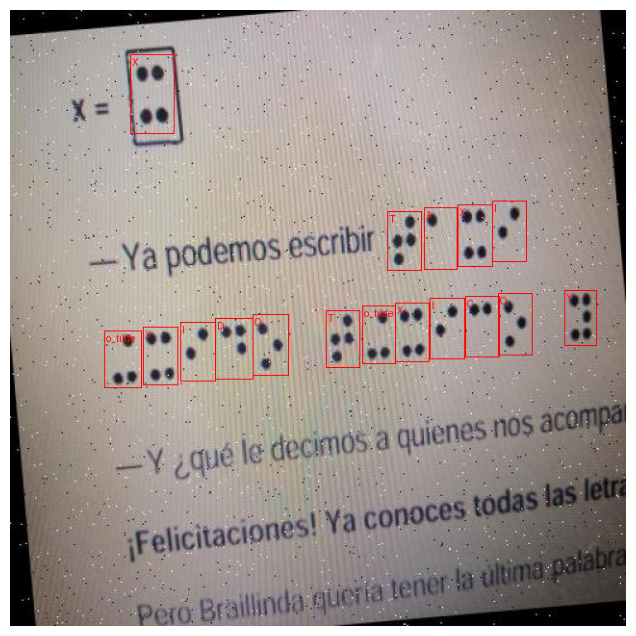

In [ ]:
# Miramos una muestra y sus anotaciones
# Check a sample and its annotations
labels_map = {
    0: 'background', 1: 'A', 2: 'B', 3: 'C', 4: 'D', 5: 'E', 6: 'F', 7: 'G', 8: 'H', 9: 'I', 10: 'J', 11: 'K', 12: 'L', 13: 'M', 14: 'N', 15: 'O', 16: 'P', 17: 'Q', 18: 'R', 19: 'S', 20: 'T', 21: 'U', 22: 'V', 23: 'W', 24: 'X', 25: 'Y', 26: 'Z', 27: 'a_tilde', 28: 'ampersand', 29: 'apostrophe', 30: 'asterisk', 31: 'capital', 32: 'close_parenthesis', 33: 'closequotatioN', 34: 'colon', 35: 'comma', 36: 'e_tilde', 37: 'exclamation_mark', 38: 'greaterthan', 39: 'hyphen', 40: 'i_tilde', 41: 'lessthan', 42: 'letter_sign', 43: 'minus', 44: 'n_tilde', 45: 'number_sign', 46: 'o_tilde', 47: 'open_parenthesis', 48: 'parentheses', 49: 'period', 50: 'question_mark', 51: 'semicolon', 52: 'slash', 53: 'u_dieresis', 54: 'u_tilde'
}


figure = plt.figure(figsize=(8, 8))
sample_idx = torch.randint(len(train_dataset), size=(1,)).item()
img, label = train_dataset[sample_idx]

# Convert numerical labels to class names for display
label_names = [labels_map[lbl.item()] for lbl in label['labels']]

# We use the drawing method from Pytorch
drawn_boxes = draw_bounding_boxes(
    (img * 255).to(torch.uint8),
    label['boxes'],
    labels=label_names,
    colors="red"
)
plt.imshow(drawn_boxes.permute(1, 2, 0))
plt.axis("off")
plt.show()

### Entrenamos el Faster RCNN con una Resnet50 como backbone

In [ ]:
# Load Faster R-CNN with ResNet-50 backbone
def get_model(num_classes):
    # load a model pre-trained on COCO
    model = torchvision.models.detection.fasterrcnn_resnet50_fpn(weights="COCO_V1")

    # get number of input features for the classifier
    in_features = model.roi_heads.box_predictor.cls_score.in_features

    # replace the pre-trained head with a new one
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)
    return model

In [ ]:
# Initialize the model
num_classes = 55 # 54 classes + background
model = get_model(num_classes)

Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth


100%|██████████| 160M/160M [00:00<00:00, 232MB/s]


In [ ]:
# Move model to GPU if available
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
print(torch.cuda.is_available())
model.to(device)

# Define optimizer and learning rate scheduler
params = [p for p in model.parameters() if p.requires_grad]
optimizer = torch.optim.SGD(params, lr=0.005, momentum=0.9, weight_decay=0.0005)
lr_scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.1)

True


In [ ]:
num_epochs = 25
loss_fasterrcnn, map_fasterrcnn = training_loop(model, optimizer, train_loader, device, num_epochs, print_freq=100, save_dir="FasterRCNN")

Epoch [0]
-------------------------------------------------------------------------------------------------------------------------------------------------


/content/drive/MyDrive/Trabajo de Grado/engine.py:30: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=scaler is not None):


Epoch: [0]  [  0/802]  eta: 0:05:02  lr: 0.000011  loss: 6.4707 (6.4707)  loss_classifier: 4.3555 (4.3555)  loss_box_reg: 0.2265 (0.2265)  loss_objectness: 1.7586 (1.7586)  loss_rpn_box_reg: 0.1301 (0.1301)  time: 0.3777  data: 0.0219  max mem: 5969
Epoch: [0]  [100/802]  eta: 0:04:29  lr: 0.000635  loss: 1.7072 (2.5421)  loss_classifier: 0.9761 (1.5537)  loss_box_reg: 0.5948 (0.5356)  loss_objectness: 0.0702 (0.3760)  loss_rpn_box_reg: 0.0384 (0.0768)  time: 0.3876  data: 0.0242  max mem: 5969
Epoch: [0]  [200/802]  eta: 0:03:50  lr: 0.001258  loss: 1.4618 (2.0185)  loss_classifier: 0.7529 (1.1917)  loss_box_reg: 0.5042 (0.5487)  loss_objectness: 0.0414 (0.2189)  loss_rpn_box_reg: 0.0334 (0.0592)  time: 0.3841  data: 0.0248  max mem: 5969
Epoch: [0]  [300/802]  eta: 0:03:12  lr: 0.001882  loss: 1.1538 (1.7708)  loss_classifier: 0.6597 (1.0321)  loss_box_reg: 0.4369 (0.5288)  loss_objectness: 0.0192 (0.1588)  loss_rpn_box_reg: 0.0305 (0.0512)  time: 0.3805  data: 0.0231  max mem: 5969


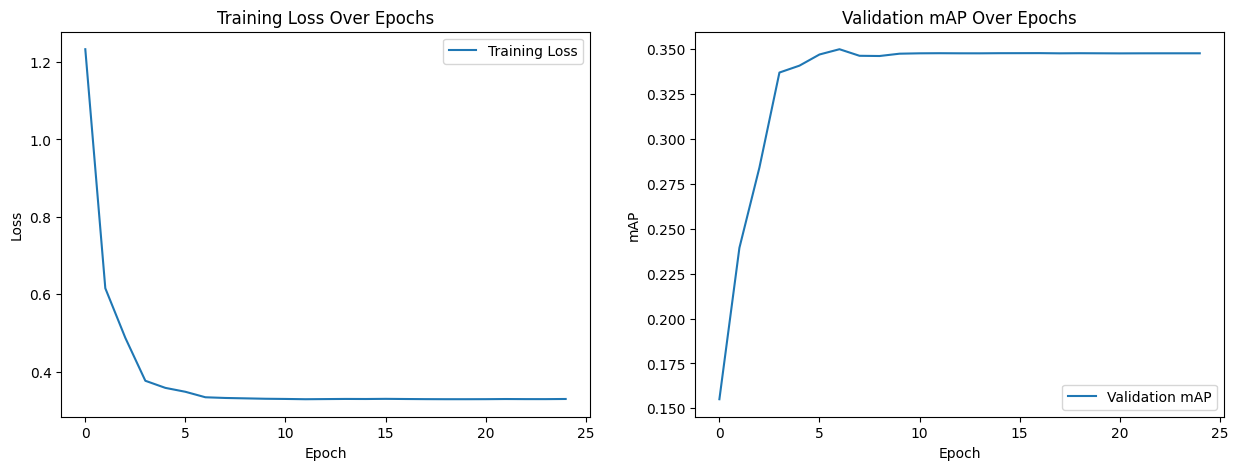

In [ ]:
# Extract numerical loss from MetricLogger objects
processed_training_loss = []
for metric_logger_obj in loss_fasterrcnn:
    if 'loss' in metric_logger_obj.meters:
        # MetricLogger often stores various losses, and 'loss' itself is an AverageMeter. We need the average of the main loss for the epoch
        processed_training_loss.append(metric_logger_obj.meters['loss'].global_avg)
    else:
        # Handle cases where 'loss' might not be directly available
        processed_training_loss.append(float('nan')) # Append NaN or 0 if loss isn't found

plt.figure(figsize=(15,5))
plt.subplot(1,2,1)

plt.plot(processed_training_loss, label='Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss Over Epochs')
plt.legend()

plt.subplot(1,2,2)
plt.plot(map_fasterrcnn, label='Validation mAP')
plt.xlabel('Epoch')
plt.ylabel('mAP')
plt.title('Validation mAP Over Epochs')
plt.legend()
plt.show()

In [ ]:
# Load the trained model
num_classes = 55 # 54 classes + background
model = get_model(num_classes)
model.load_state_dict(torch.load("FasterRCNN/best_fasterrcnn_resnet50.pth"))
model.to(device)
model.eval()  # Set the model to evaluation mode

metrics_fasterrcnn = evaluate(model, val_loader, device)

Test:  [  0/100]  eta: 0:00:21  model_time: 0.1613 (0.1613)  evaluator_time: 0.0207 (0.0207)  time: 0.2118  data: 0.0250  max mem: 5969
Test:  [ 99/100]  eta: 0:00:00  model_time: 0.1589 (0.1588)  evaluator_time: 0.0177 (0.0199)  time: 0.2089  data: 0.0258  max mem: 5969
Test: Total time: 0:00:20 (0.2092 s / it)
Averaged stats: model_time: 0.1589 (0.1588)  evaluator_time: 0.0177 (0.0199)
Accumulating evaluation results...
DONE (t=0.66s).
IoU metric: bbox
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.350
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.550
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.418
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.200
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.436
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.566
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | max

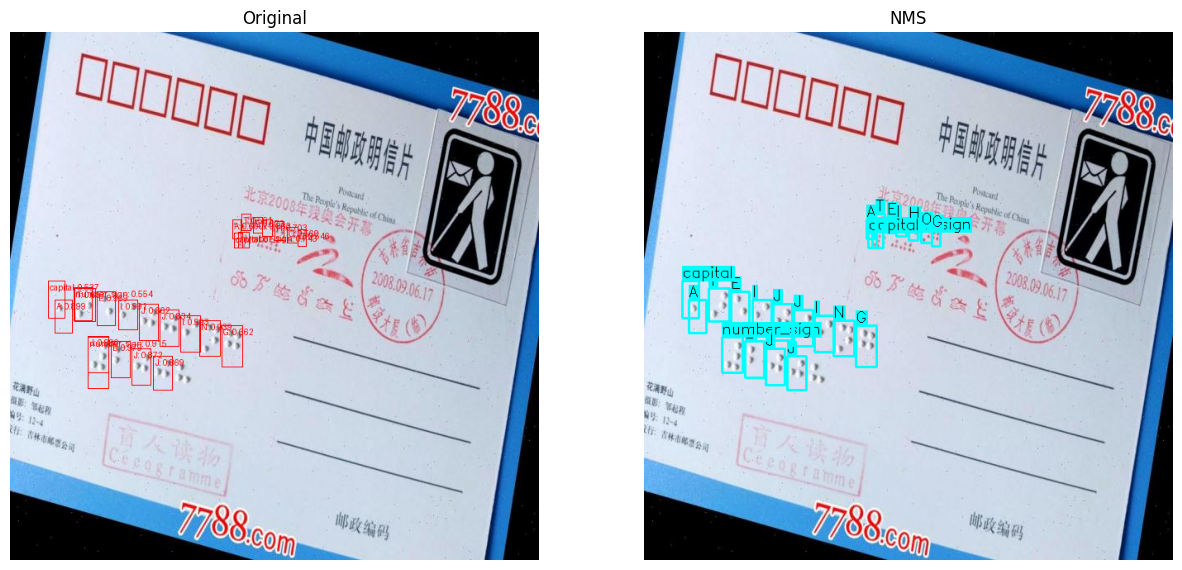

----------------------------------------
aNUMBER_SIGNt ei h o g
A t5bijj j i n g
j
----------------------------------------


In [ ]:
import matplotlib.pyplot as plt
from torchvision.io import read_image
from torchvision.utils import draw_bounding_boxes, draw_segmentation_masks
from torchvision.transforms import v2 as T
from google.colab.patches import cv2_imshow

labels_map = {
    0: 'background', 1: 'A', 2: 'B', 3: 'C', 4: 'D', 5: 'E', 6: 'F', 7: 'G', 8: 'H', 9: 'I', 10: 'J', 11: 'K', 12: 'L', 13: 'M', 14: 'N', 15: 'O', 16: 'P', 17: 'Q', 18: 'R', 19: 'S', 20: 'T', 21: 'U', 22: 'V', 23: 'W', 24: 'X', 25: 'Y', 26: 'Z', 27: 'a_tilde', 28: 'ampersand', 29: 'apostrophe', 30: 'asterisk', 31: 'capital', 32: 'close_parenthesis', 33: 'closequotatioN', 34: 'colon', 35: 'comma', 36: 'e_tilde', 37: 'exclamation_mark', 38: 'greaterthan', 39: 'hyphen', 40: 'i_tilde', 41: 'lessthan', 42: 'letter_sign', 43: 'minus', 44: 'n_tilde', 45: 'number_sign', 46: 'o_tilde', 47: 'open_parenthesis', 48: 'parentheses', 49: 'period', 50: 'question_mark', 51: 'semicolon', 52: 'slash', 53: 'u_dieresis', 54: 'u_tilde'
}

sample_idx = torch.randint(len(test_dataset), size=(1,)).item()
sample = test_dataset[sample_idx]
image = sample[0]

# Load the trained model
num_classes = 55 # 54 classes + background
model = get_model(num_classes)
model.load_state_dict(torch.load("FasterRCNN/best_fasterrcnn_resnet50.pth"))
model.to(device)
model.eval()  # Set the model to evaluation mode

with torch.no_grad():
    x = image
    # convert RGBA -> RGB and move to device
    x = x[:3, ...].to(device)
    predictions = model([x, ])
    pred = predictions[0]


image = (255.0 * (image - image.min()) / (image.max() - image.min())).to(torch.uint8)
image = image[:3, ...]

threshold = 0.5
pred = {
    'boxes': pred['boxes'][pred['scores'] > threshold].cpu(),
    'labels': pred['labels'][pred['scores'] > threshold].cpu(),
    'scores': pred['scores'][pred['scores'] > threshold].cpu()
}

# Convert numerical labels to class names for display
label_names = [labels_map[lbl.item()] for lbl in pred['labels']]
pred_labels = [f"{label}: {score:.3f}" for label, score in zip(label_names, pred["scores"])]
pred_labels_names = [f"{label}: {score:.3f}" for label, score in zip(label_names, pred["scores"])]
pred_boxes = pred["boxes"].long()
output_image = draw_bounding_boxes(image, pred_boxes, pred_labels_names, colors="red")

#Apply NMS
nms_results, text_results = nms_Pytorch(pred, test_dataset, sample_idx, labels_map, iou_threshold=0.3)

plt.figure(figsize=(15, 15))
plt.subplot(1,2,1)
plt.title("Original")
plt.imshow(output_image.permute(1, 2, 0))
plt.axis("off")

plt.subplot(1,2,2)
plt.title("NMS")
plt.imshow(nms_results)
plt.axis("off")
plt.show()

print("----------------------------------------")
for line in text_results:
    print(line)
print("----------------------------------------")

In [ ]:
play_text("".join(text_results))

### Ahora entrenemos una RetinaNet

In [ ]:
# Load RetinaNet with ResNet-50 backbone
num_classes = 55

def get_model(num_custom_classes):
    # Load pre-trained RetinaNet with COCO weights.

    model = retinanet_resnet50_fpn_v2(weights=RetinaNet_ResNet50_FPN_V2_Weights.COCO_V1)

    # Get the number of input channels for the classification head from the FPN backbone.
    in_channels = model.backbone.out_channels

    # Get the number of anchors used by the original RetinaNet head.
    num_anchors = model.head.classification_head.num_anchors

    # Replace the classification head with a new one for the custom number of classes.
    model.head.classification_head = torchvision.models.detection.retinanet.RetinaNetClassificationHead(
        in_channels=in_channels,
        num_anchors=num_anchors,
        num_classes=num_custom_classes
    )
    return model

model = get_model(num_classes)

In [ ]:
# Move model to GPU if available
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
print(torch.cuda.is_available())
model.to(device)

params = [p for p in model.parameters() if p.requires_grad]
optimizer = torch.optim.SGD(params, lr=0.005, momentum=0.9, weight_decay=0.0005)
lr_scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.1)

True


In [ ]:
num_epochs = 15
loss_retina, map_retina = training_loop(model, optimizer, train_loader, device, num_epochs, print_freq=100, save_dir="RetinaNet")

Epoch [0]
-------------------------------------------------------------------------------------------------------------------------------------------------


/content/drive/MyDrive/Trabajo de Grado/engine.py:30: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=scaler is not None):


Epoch: [0]  [  0/802]  eta: 0:06:55  lr: 0.000011  loss: 1.5645 (1.5645)  classification: 1.1610 (1.1610)  bbox_regression: 0.4035 (0.4035)  time: 0.5184  data: 0.0232  max mem: 5969
Epoch: [0]  [100/802]  eta: 0:04:35  lr: 0.000635  loss: 1.5337 (1.5587)  classification: 1.1723 (1.1821)  bbox_regression: 0.3606 (0.3766)  time: 0.3902  data: 0.0223  max mem: 6010
Epoch: [0]  [200/802]  eta: 0:03:55  lr: 0.001258  loss: 1.4886 (1.5345)  classification: 1.1595 (1.1761)  bbox_regression: 0.3314 (0.3584)  time: 0.3866  data: 0.0218  max mem: 6010
Epoch: [0]  [300/802]  eta: 0:03:16  lr: 0.001882  loss: 1.3329 (1.5036)  classification: 1.0303 (1.1542)  bbox_regression: 0.3329 (0.3494)  time: 0.3909  data: 0.0228  max mem: 6010
Epoch: [0]  [400/802]  eta: 0:02:36  lr: 0.002506  loss: 1.2849 (1.4518)  classification: 1.0205 (1.1117)  bbox_regression: 0.2866 (0.3400)  time: 0.3911  data: 0.0233  max mem: 6010
Epoch: [0]  [500/802]  eta: 0:01:57  lr: 0.003129  loss: 1.3152 (1.3954)  classificat

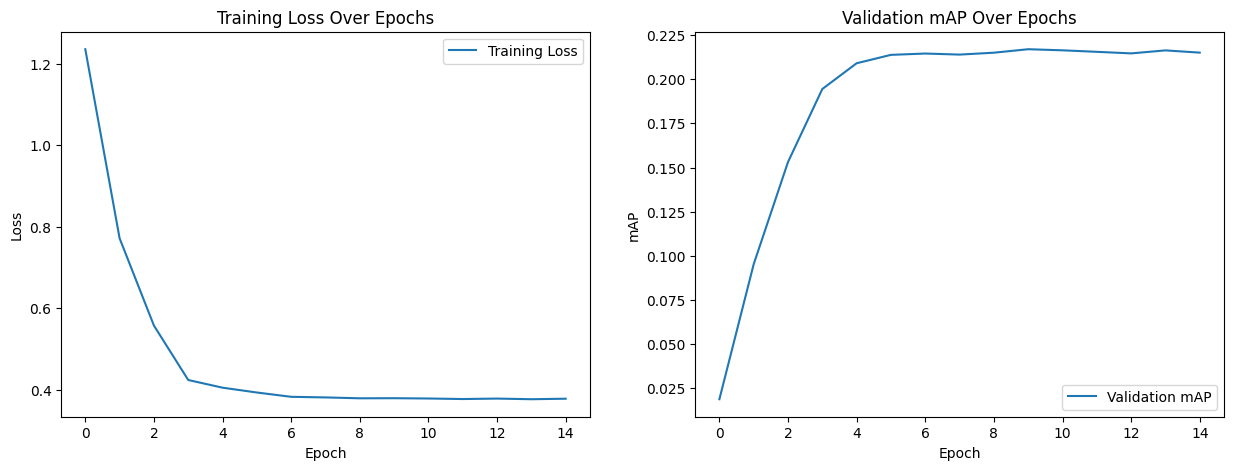

In [ ]:
# Extract numerical loss from MetricLogger objects
processed_training_loss = []
for metric_logger_obj in loss_retina:
    if 'loss' in metric_logger_obj.meters:
        # MetricLogger often stores various losses, and 'loss' itself is an AverageMeter. We need the average of the main loss for the epoch
        processed_training_loss.append(metric_logger_obj.meters['loss'].global_avg)
    else:
        # Handle cases where 'loss' might not be directly available
        processed_training_loss.append(float('nan')) # Append NaN or 0 if loss isn't found

plt.figure(figsize=(15,5))
plt.subplot(1,2,1)

plt.plot(processed_training_loss, label='Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss Over Epochs')
plt.legend()

plt.subplot(1,2,2)
plt.plot(map_retina, label='Validation mAP')
plt.xlabel('Epoch')
plt.ylabel('mAP')
plt.title('Validation mAP Over Epochs')
plt.legend()
plt.show()

In [ ]:
# Load the trained model
num_classes = 55 # 54 classes + background
model = get_model(num_classes)
model.load_state_dict(torch.load("RetinaNet/best_RetinaNet.pth"))
model.to(device)
model.eval()  # Set the model to evaluation mode

metrics_Retina = evaluate(model, test_loader, device)

Test:  [  0/100]  eta: 0:00:20  model_time: 0.1297 (0.1297)  evaluator_time: 0.0375 (0.0375)  time: 0.2002  data: 0.0282  max mem: 6100
Test:  [ 99/100]  eta: 0:00:00  model_time: 0.1292 (0.1288)  evaluator_time: 0.0408 (0.0526)  time: 0.7463  data: 0.5319  max mem: 6100
Test: Total time: 0:00:31 (0.3154 s / it)
Averaged stats: model_time: 0.1292 (0.1288)  evaluator_time: 0.0408 (0.0526)
Accumulating evaluation results...
DONE (t=1.52s).
IoU metric: bbox
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.216
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.392
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.218
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.106
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.257
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.472
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | max

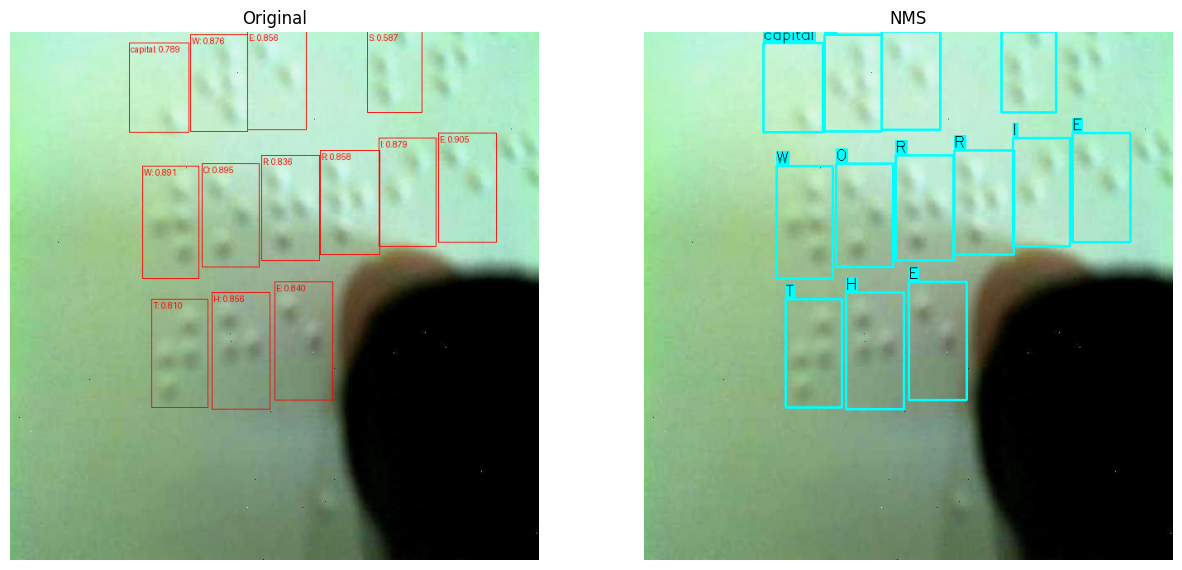

----------------------------------------
WE S
capitalWORRIE
THE
----------------------------------------


In [ ]:
import matplotlib.pyplot as plt
from torchvision.io import read_image
from torchvision.utils import draw_bounding_boxes, draw_segmentation_masks
from torchvision.transforms import v2 as T

labels_map = {
    0: 'background', 1: 'A', 2: 'B', 3: 'C', 4: 'D', 5: 'E', 6: 'F', 7: 'G', 8: 'H', 9: 'I', 10: 'J', 11: 'K', 12: 'L', 13: 'M', 14: 'N', 15: 'O', 16: 'P', 17: 'Q', 18: 'R', 19: 'S', 20: 'T', 21: 'U', 22: 'V', 23: 'W', 24: 'X', 25: 'Y', 26: 'Z', 27: 'a_tilde', 28: 'ampersand', 29: 'apostrophe', 30: 'asterisk', 31: 'capital', 32: 'close_parenthesis', 33: 'closequotatioN', 34: 'colon', 35: 'comma', 36: 'e_tilde', 37: 'exclamation_mark', 38: 'greaterthan', 39: 'hyphen', 40: 'i_tilde', 41: 'lessthan', 42: 'letter_sign', 43: 'minus', 44: 'n_tilde', 45: 'number_sign', 46: 'o_tilde', 47: 'open_parenthesis', 48: 'parentheses', 49: 'period', 50: 'question_mark', 51: 'semicolon', 52: 'slash', 53: 'u_dieresis', 54: 'u_tilde'
}

sample_idx = torch.randint(len(test_dataset), size=(1,)).item()
sample = test_dataset[sample_idx]
image = sample[0]

# Load the trained model
num_classes = 55 # 54 classes + background
model = get_model(num_classes)
model.load_state_dict(torch.load("RetinaNet/best_RetinaNet.pth"))
model.to(device)
model.eval()  # Set the model to evaluation mode
with torch.no_grad():
    x = image
    # convert RGBA -> RGB and move to device
    x = x[:3, ...].to(device)
    predictions = model([x, ])
    pred = predictions[0]


image = (255.0 * (image - image.min()) / (image.max() - image.min())).to(torch.uint8)
image = image[:3, ...]

threshold = 0.5
pred = {
    'boxes': pred['boxes'][pred['scores'] > threshold].cpu(),
    'labels': pred['labels'][pred['scores'] > threshold].cpu(),
    'scores': pred['scores'][pred['scores'] > threshold].cpu()
}

# Convert numerical labels to class names for display
label_names = [labels_map[lbl.item()] for lbl in pred['labels']]
pred_labels = [f"{label}: {score:.3f}" for label, score in zip(label_names, pred["scores"])]
pred_labels_names = [f"{label}: {score:.3f}" for label, score in zip(label_names, pred["scores"])]
pred_boxes = pred["boxes"].long()
output_image = draw_bounding_boxes(image, pred_boxes, pred_labels_names, colors="red")

#Apply NMS
nms_results, text_results = nms_Pytorch(pred, test_dataset, sample_idx, labels_map, iou_threshold=0.3)

plt.figure(figsize=(15, 15))
plt.subplot(1,2,1)
plt.title("Original")
plt.imshow(output_image.permute(1, 2, 0))
plt.axis("off")

plt.subplot(1,2,2)
plt.title("NMS")
plt.imshow(nms_results)
plt.axis("off")
plt.show()

print("----------------------------------------")
for line in text_results:
    print(line)
print("----------------------------------------")

### Ahora Entrenemos un SSD

In [ ]:
def get_model(num_classes):
    #Initialize the model
    model = torchvision.models.detection.ssdlite320_mobilenet_v3_large(weights="DEFAULT")

    #Get params to replace both heads of the model.
    in_channels = det_utils.retrieve_out_channels(model.backbone, (320, 320))
    num_anchors = model.anchor_generator.num_anchors_per_location()
    norm_layer  = partial(nn.BatchNorm2d, eps=0.001, momentum=0.03)

    model.head = SSDLiteHead(in_channels, num_anchors, num_classes, norm_layer)

    return model

In [ ]:
num_classes = 55
model = get_model(num_classes)

In [ ]:
# Move model to GPU if available
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
print(torch.cuda.is_available())
model.to(device)

params = [p for p in model.parameters() if p.requires_grad]
optimizer = torch.optim.SGD(params, lr=0.005, momentum=0.9, weight_decay=0.0005)
lr_scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.1)

True


In [ ]:
num_epochs = 25
loss_SSD, map_SSD = training_loop(model, optimizer, train_loader, device, num_epochs, print_freq=100, save_dir="SSDLite")

Epoch [0]
-------------------------------------------------------------------------------------------------------------------------------------------------


/content/drive/MyDrive/Trabajo de Grado/engine.py:30: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=scaler is not None):


Epoch: [0]  [  0/802]  eta: 0:04:39  lr: 0.000011  loss: 31.4993 (31.4993)  bbox_regression: 13.9572 (13.9572)  classification: 17.5421 (17.5421)  time: 0.3489  data: 0.0230  max mem: 6100
Epoch: [0]  [100/802]  eta: 0:00:57  lr: 0.000635  loss: 17.8013 (21.1601)  bbox_regression: 2.3256 (4.6241)  classification: 15.6297 (16.5360)  time: 0.0805  data: 0.0231  max mem: 6100
Epoch: [0]  [200/802]  eta: 0:00:48  lr: 0.001258  loss: 15.2713 (19.3797)  bbox_regression: 2.3649 (3.9415)  classification: 13.1802 (15.4382)  time: 0.0807  data: 0.0237  max mem: 6100
Epoch: [0]  [300/802]  eta: 0:00:40  lr: 0.001882  loss: 8.5866 (16.9724)  bbox_regression: 1.4712 (3.4444)  classification: 7.2973 (13.5280)  time: 0.0805  data: 0.0229  max mem: 6100
Epoch: [0]  [400/802]  eta: 0:00:32  lr: 0.002506  loss: 7.3460 (14.8283)  bbox_regression: 1.4156 (3.0722)  classification: 5.8383 (11.7561)  time: 0.0786  data: 0.0218  max mem: 6100
Epoch: [0]  [500/802]  eta: 0:00:24  lr: 0.003129  loss: 7.0235 (13

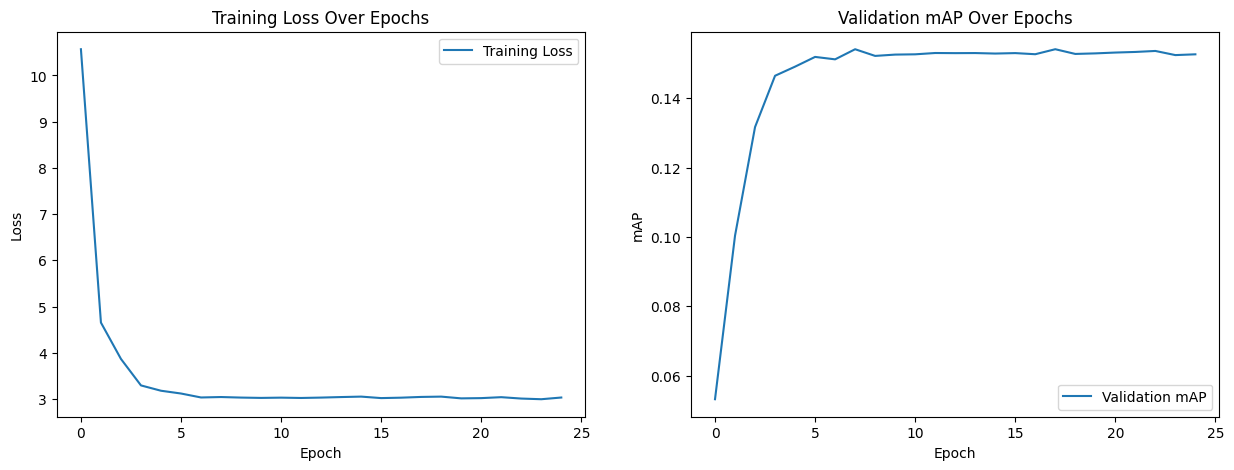

In [ ]:
# Extract numerical loss from MetricLogger objects
processed_training_loss = []
for metric_logger_obj in loss_SSD:
    if 'loss' in metric_logger_obj.meters:
        # MetricLogger often stores various losses, and 'loss' itself is an AverageMeter. We need the average of the main loss for the epoch
        processed_training_loss.append(metric_logger_obj.meters['loss'].global_avg)
    else:
        # Handle cases where 'loss' might not be directly available
        processed_training_loss.append(float('nan')) # Append NaN or 0 if loss isn't found

plt.figure(figsize=(15,5))
plt.subplot(1,2,1)

plt.plot(processed_training_loss, label='Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss Over Epochs')
plt.legend()

plt.subplot(1,2,2)
plt.plot(map_SSD, label='Validation mAP')
plt.xlabel('Epoch')
plt.ylabel('mAP')
plt.title('Validation mAP Over Epochs')
plt.legend()
plt.show()

In [ ]:
# Load the trained model
num_classes = 55 # 54 classes + background
model = get_model(num_classes)
model.load_state_dict(torch.load("SSDLite/best_SSDLite.pth"))
model.to(device)
model.eval()  # Set the model to evaluation mode

metrics_SSD = evaluate(model, test_loader, device)

Test:  [  0/100]  eta: 0:00:15  model_time: 0.0670 (0.0670)  evaluator_time: 0.0579 (0.0579)  time: 0.1544  data: 0.0249  max mem: 6100
Test:  [ 99/100]  eta: 0:00:00  model_time: 0.0749 (0.0753)  evaluator_time: 0.0545 (0.0774)  time: 0.2037  data: 0.0273  max mem: 6100
Test: Total time: 0:00:18 (0.1856 s / it)
Averaged stats: model_time: 0.0749 (0.0753)  evaluator_time: 0.0545 (0.0774)
Accumulating evaluation results...
DONE (t=1.96s).
IoU metric: bbox
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.159
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.272
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.170
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.001
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.194
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.526
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | max

<Figure size 800x800 with 0 Axes>

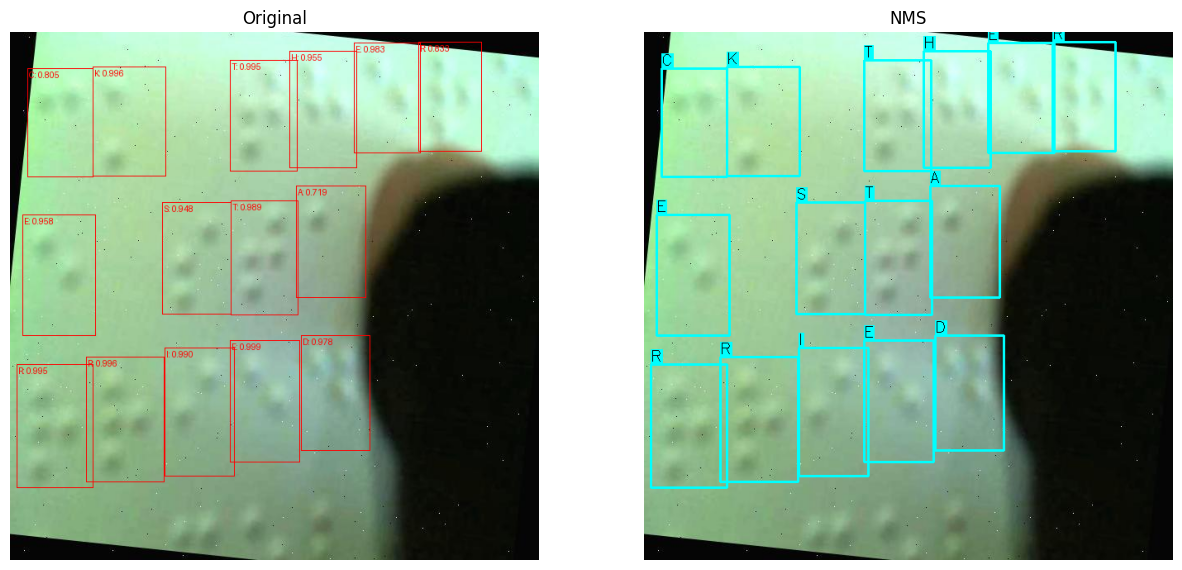

----------------------------------------
CK THAER
E ST
RRIED
----------------------------------------


In [ ]:
import matplotlib.pyplot as plt
from torchvision.io import read_image
from torchvision.utils import draw_bounding_boxes, draw_segmentation_masks
from torchvision.transforms import v2 as T

labels_map = {
    0: 'background', 1: 'A', 2: 'B', 3: 'C', 4: 'D', 5: 'E', 6: 'F', 7: 'G', 8: 'H', 9: 'I', 10: 'J', 11: 'K', 12: 'L', 13: 'M', 14: 'N', 15: 'O', 16: 'P', 17: 'Q', 18: 'R', 19: 'S', 20: 'T', 21: 'U', 22: 'V', 23: 'W', 24: 'X', 25: 'Y', 26: 'Z', 27: 'a_tilde', 28: 'ampersand', 29: 'apostrophe', 30: 'asterisk', 31: 'capital', 32: 'close_parenthesis', 33: 'closequotatioN', 34: 'colon', 35: 'comma', 36: 'e_tilde', 37: 'exclamation_mark', 38: 'greaterthan', 39: 'hyphen', 40: 'i_tilde', 41: 'lessthan', 42: 'letter_sign', 43: 'minus', 44: 'n_tilde', 45: 'number_sign', 46: 'o_tilde', 47: 'open_parenthesis', 48: 'parentheses', 49: 'period', 50: 'question_mark', 51: 'semicolon', 52: 'slash', 53: 'u_dieresis', 54: 'u_tilde'
}

figure = plt.figure(figsize=(8, 8))
sample_idx = torch.randint(len(test_dataset), size=(1,)).item()
sample = test_dataset[sample_idx]
image = sample[0]

num_classes = 55 # 54 classes + background
model = get_model(num_classes)
model.load_state_dict(torch.load("SSDLite/best_SSDLite.pth"))
model.to(device)
model.eval()  # Set the model to evaluation mode
with torch.no_grad():
    x = image
    # convert RGBA -> RGB and move to device
    x = x[:3, ...].to(device)
    predictions = model([x, ])
    pred = predictions[0]


image = (255.0 * (image - image.min()) / (image.max() - image.min())).to(torch.uint8)
image = image[:3, ...]

threshold = 0.5
pred = {
    'boxes': pred['boxes'][pred['scores'] > threshold].cpu(),
    'labels': pred['labels'][pred['scores'] > threshold].cpu(),
    'scores': pred['scores'][pred['scores'] > threshold].cpu()
}

# Convert numerical labels to class names for display
label_names = [labels_map[lbl.item()] for lbl in pred['labels']]
pred_labels = [f"{label}: {score:.3f}" for label, score in zip(label_names, pred["scores"])]
pred_labels_names = [f"{label}: {score:.3f}" for label, score in zip(label_names, pred["scores"])]
pred_boxes = pred["boxes"].long()
output_image = draw_bounding_boxes(image, pred_boxes, pred_labels_names, colors="red")

#Apply NMS
nms_results, text_results = nms_Pytorch(pred, test_dataset, sample_idx, labels_map, iou_threshold=0.3)

plt.figure(figsize=(15, 15))
plt.subplot(1,2,1)
plt.title("Original")
plt.imshow(output_image.permute(1, 2, 0))
plt.axis("off")

plt.subplot(1,2,2)
plt.title("NMS")
plt.imshow(nms_results)
plt.axis("off")
plt.show()

print("----------------------------------------")
for line in text_results:
    print(line)
print("----------------------------------------")

## Vamos a comparar metricas

In [ ]:
print("-----------------------------------------------------------------------")
print("Best mAP50:95")
print("Yolov8: ", metrics_Yolov8.box.map)
print("Yolo26: ", metrics_Yolo26.box.map)
print("RT-DETR: ", metrics_Trans.box.map)
print("FasterRCNN: ", metrics_fasterrcnn.coco_eval['bbox'].stats[0])
print("RetinaNet: ", metrics_Retina.coco_eval['bbox'].stats[0])
print("SSDLite: ", metrics_SSD.coco_eval['bbox'].stats[0])
print("-----------------------------------------------------------------------")
print("-----------------------------------------------------------------------")
print("Best mAP50")
print("Yolov8: ", metrics_Yolov8.box.map50)
print("Yolo26: ", metrics_Yolo26.box.map50)
print("RT-DETR: ", metrics_Trans.box.map50)
print("FasterRCNN: ", metrics_fasterrcnn.coco_eval['bbox'].stats[1])
print("RetinaNet: ", metrics_Retina.coco_eval['bbox'].stats[1])
print("SSDLite: ", metrics_SSD.coco_eval['bbox'].stats[1])
print("-----------------------------------------------------------------------")


-----------------------------------------------------------------------
Best mAP50:95
Yolov8:  0.6010157209416762
Yolo26:  0.551659176341461
RT-DETR:  0.6330334710958984
FasterRCNN:  0.15417890276960675
RetinaNet:  0.21595528977558742
SSDLite:  0.15873331914457495
-----------------------------------------------------------------------
-----------------------------------------------------------------------
Best mAP50
Yolov8:  0.8436290176467125
Yolo26:  0.7662751635553717
RT-DETR:  0.873200621260977
FasterRCNN:  0.26459256497797734
RetinaNet:  0.39239767632740175
SSDLite:  0.27174579029437634
-----------------------------------------------------------------------
